# Correspondence Analysis (CA): periods, gender, country, occupation, field


## Documentation
* [Correspondence Analysis](https://en.wikipedia.org/wiki/Correspondence_analysis) (Wikipedia)
* [CA - Correspondence Analysis in R: Essentials](https://www.sthda.com/english/articles/31-principal-component-methods-in-r-practical-guide/113-ca-correspondence-analysis-in-r-essentials/)

* [Analyse factorielle des correspondances](https://fr.wikipedia.org/wiki/Analyse_factorielle_des_correspondances) (Wikipedia)
* [Analyse factorielle des correspondances](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/statistiques_descriptives/analyse_factorielle_correspondances_manuels.ipynb)


### Add fanalysis library to pip environment

* Open a terminal and activate your data analysis environment:

    -> my_venvs_activate data_analysis
* Install the missing package in the active environment:

    -> pip install fanalysis
* Deactivate the environment when you have finished:

    -> my_venvs_deactivate


In [1]:
### Activate libraries that will be used in the notebook

import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

import fanalysis.ca as fa 


import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

In [2]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [3]:

import bivariate_library as bl
import correspondence_analysis_library as cal


In [4]:
### Use this to reload the functions if modified
print(reload(bl))
print(reload(cal))  

<module 'bivariate_library' from '/home/ministers/da4_data/bivariate_library.py'>
<module 'correspondence_analysis_library' from '/home/ministers/da4_data/correspondence_analysis_library.py'>


In [5]:
import warnings
warnings.filterwarnings('ignore')


## 
Create a dataframe with the data to be analysed

In this notebook, we use the data produced in the da3-1 notebook: a list of individuals with three qualitative variables — coded gender, country of birth and period of activity.

The CA-based analysis results produced in this notebook are therefore based on the same data and complement the bivariate analysis carried out in notebook da3-1.

Of course, you can use regions instead of countries or other territories, as in notebook da3. The important point is to use the same data as in the bivariate analysis notebook to observe the differences between the two approaches. 



In [6]:
csv_address='da4-AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0,Nord,1909.0,1907-1926


In [7]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   uriPer              561 non-null    object 
 1   labelPer            559 non-null    object 
 2   birthYear           561 non-null    float64
 3   gender              561 non-null    object 
 4   labelPlace          561 non-null    object 
 5   geometry            561 non-null    object 
 6   uriPlace            561 non-null    object 
 7   periods             561 non-null    object 
 8   index_right         561 non-null    float64
 9   reg_name            561 non-null    object 
 10  reg_istat_code_num  561 non-null    float64
 11  reg_istat_code      561 non-null    float64
 12  coded_Region        561 non-null    object 
 13  activityYear        561 non-null    float64
 14  periodsActivity     561 non-null    object 
dtypes: float64(5), object(10)
memory usage: 66.0+ KB


In [8]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [9]:
df_p.head(1)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926


In [10]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

## CA : Factor analysis

Cf. documentation at the top of the notebook


NB We use self defined functions stored in these files:
* notebooks_jupyter/correspondence_analysis_library.py
* notebooks_jupyter/bivariate_library.py

In [11]:
### Option that makes all the columns visible in a notebook
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

## Gender vs country

In [12]:
def code_gender(gender: str):
    if gender == 'femmina':
        output='f'
    else:
        output='m'
    return output

In [13]:
df_p['per_gender'] = df_p.apply(lambda x: f"{x.periodsActivity}_{code_gender(x.gender)}", axis=1)

In [14]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,per_gender
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,1907-1926_m
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,1907-1926_m


In [15]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
gen_vs_country=pd.crosstab(df_p.gender, df_p.coded_Region, margins=True)

gen_vs_country

coded_Region,Centro,Nord,Sud,All
gender,,,,
femmina,13,28,18,59
maschio,114,229,159,502
All,127,257,177,561


In [16]:
observed = gen_vs_country.iloc[:-1, :-1 ]

### Chi-square test

In [17]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [18]:
expected=bl.bivariate_stats(observed)

Chi-square : 0.07 , dof : 2
p-value : 0.964
Inertia (Phi-square):  0.0
Cramer:  0.011


### CA

In [19]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['femmi...name='gender')
,col_labels,Index(['Centr...coded_Region')
,stats,True


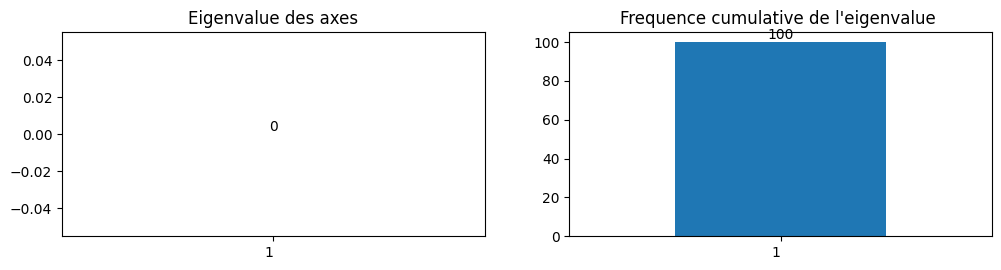

In [20]:
# Represent dimension 1 and 2
cal.print_eigenvalue(afc)

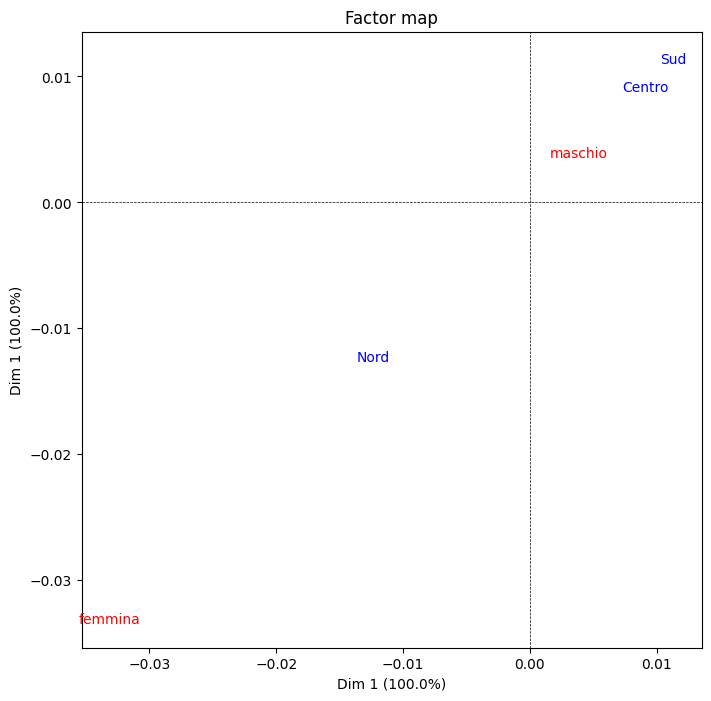

In [21]:
# Represent dimension 1 and 1
# Normally we would represent this on the horizontal axis,
# but this is not possible in the fanalysis library,
#cf. below
afc.mapping(num_x_axis=1,num_y_axis=1,figsize=(8,8))

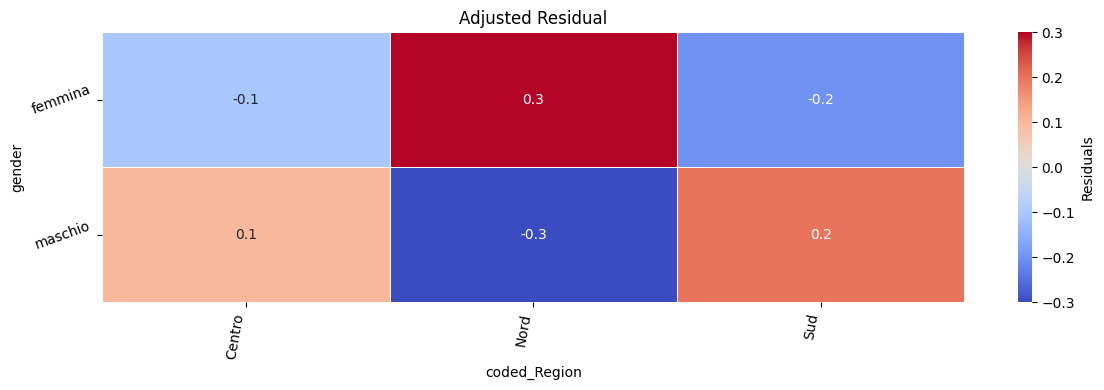

In [22]:
pp = bl.plot_chi2_residuals(observed, figsize=(12, 4))

Observations:

* we observe that Spain/Port. and South America are nearer on the CA axis to the female gender thant USA/Can.
* we also observe that China is near to USA/Can. although in the point of view of the residuals map, its value is smaller

The reason for this observation is in the way the CA code calculates the proportion of the contribution of these categories to the variation,and the representation is not linear, or depending on the position of all the other categories.


In [23]:
observed_f = observed #.loc[:, [col for col in observed.columns if col not in ['professor']]]

In [24]:
observed_f=observed_f.reindex(sorted(observed_f.columns, reverse=True), axis=1)


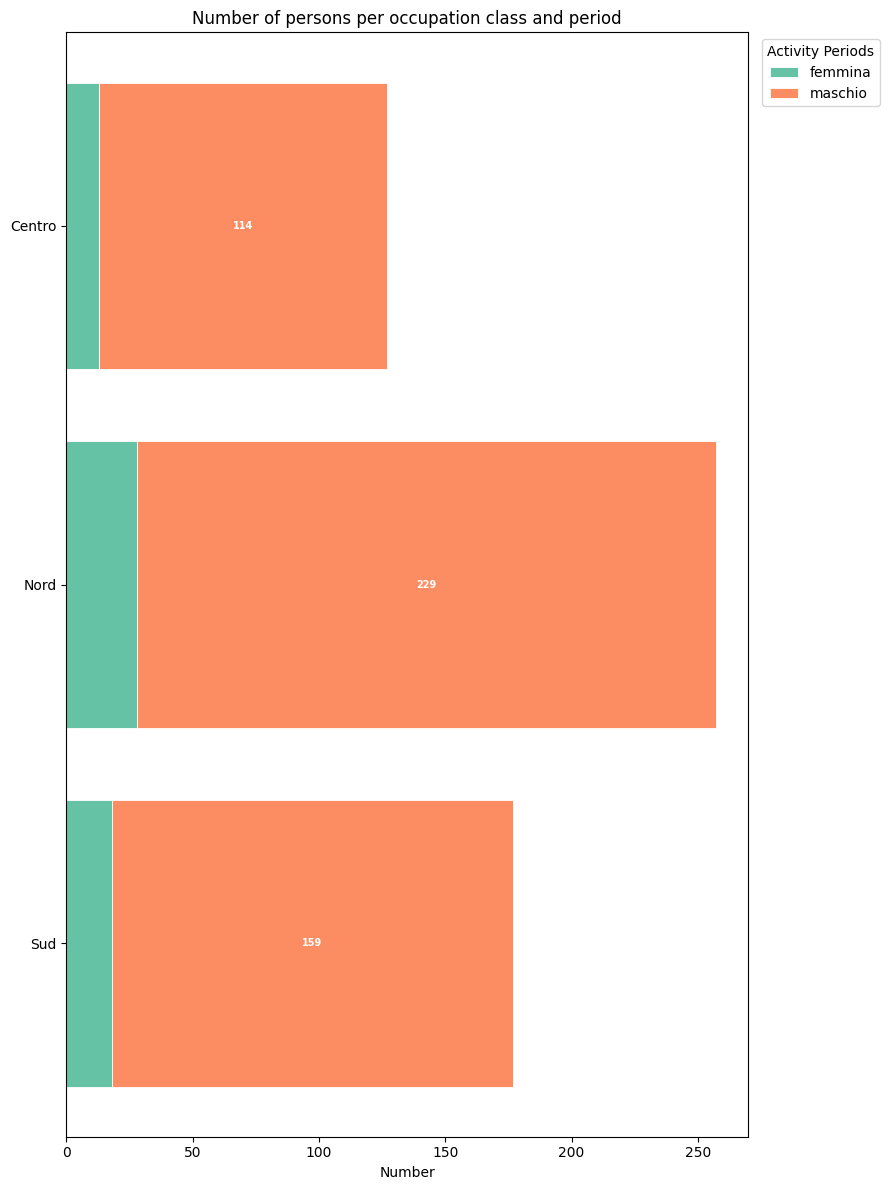

In [25]:

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 12))

colors = plt.cm.Set2.colors
lefts = np.zeros(len(observed_f.columns))  # horizontal accumulator

for i, (row_label, row_vals) in enumerate(observed_f.iterrows()):
    ax.barh(
        observed_f.columns,
        row_vals,
        left=lefts,
        color=colors[i % len(colors)],
        label=row_label,
        edgecolor='white',
        linewidth=0.6,
    )
    # Label inside each segment
    for j, (col, val) in enumerate(zip(observed_f.columns, row_vals)):
        if val > 50:
            ax.text(
                lefts[j] + val / 2, j,
                f'{int(val):,}',
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold'
            )
    lefts += row_vals.values

# --- Fix scientific notation ---
fmt = ScalarFormatter()
fmt.set_scientific(False)
fmt.set_useOffset(False)
ax.xaxis.set_major_formatter(fmt)  # x-axis now holds the counts



# --- Formatting ---
ax.set_xlabel('Number')
ax.set_title('Number of persons per occupation class and period', fontsize=12)
ax.legend(title='Activity Periods', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [26]:
observed

coded_Region,Centro,Nord,Sud
gender,,,
femmina,13,28,18
maschio,114,229,159


### Advanced observation of coordinates, contribution and cos2 (best represented)

In [27]:
dfc=pd.DataFrame([list(afc.col_coord_.round(3)),list(afc.col_contrib_.round(3)),list(afc.col_cos2_.round(3))])
dfc.columns=observed.columns
dfc.index=['coord.', 'contrib.', 'cos2 [repr. quality]']
dfc


coded_Region,Centro,Nord,Sud
coord.,[0.009],[-0.012],[0.011]
contrib.,[14.696],[53.927],[31.377]
cos2 [repr. quality],[1.0],[1.0],[1.0]


In [28]:
dfr=pd.DataFrame([list(afc.row_coord_.round(3)),list(afc.row_contrib_.round(3))])
dfr.columns=observed.index
dfr.index=['coord.', 'contrib.']
dfr


gender,femmina,maschio
coord.,[-0.033],[0.004]
contrib.,[89.483],[10.517]


In [29]:
###  fanalysis coord.

row_coords_fan = pd.DataFrame(afc.row_coord_,
                               index=observed.index,
                               columns=[f"Dim{i+1}" for i in range(afc.row_coord_.shape[1])])

col_coords_fan = pd.DataFrame(afc.col_coord_,
                               index=observed.columns,
                               columns=[f"Dim{i+1}" for i in range(afc.col_coord_.shape[1])])


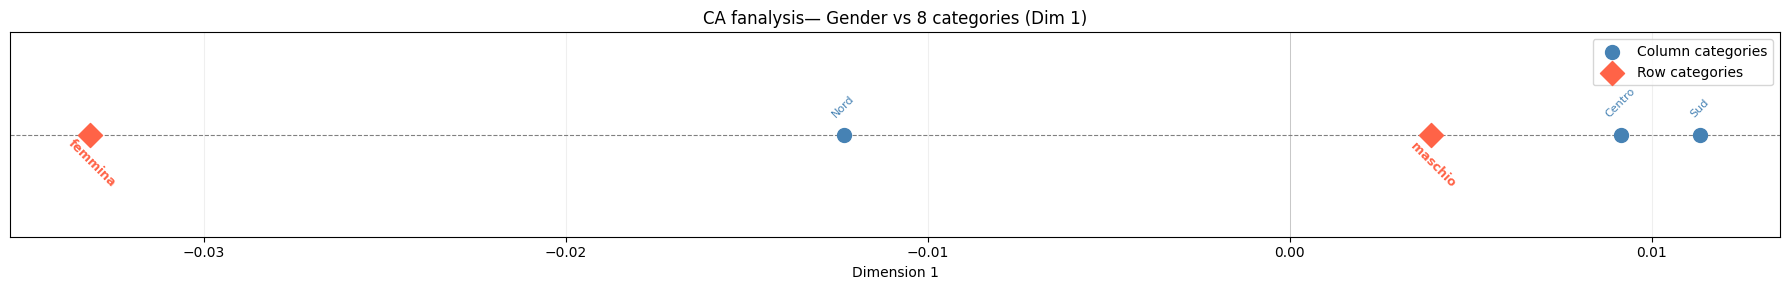

<Figure size 640x480 with 0 Axes>

In [30]:

# Usage with fanalysis
cal.plot_ca_single_axis(row_coords_fan, col_coords_fan,
                    title="CA fanalysis— Gender vs 8 categories (Dim 1)")



## Gender and period vs country

In [31]:
### Apply function and create new column
df_p['per_gender'] = df_p.apply(lambda x: f"{x.periodsActivity}_{code_gender(x.gender)}", axis=1)

In [32]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,per_gender
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,1907-1926_m
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,1907-1926_m


In [33]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
perGen_vs_country=pd.crosstab(df_p.per_gender, df_p.coded_Region, margins=True)

perGen_vs_country

coded_Region,Centro,Nord,Sud,All
per_gender,,,,
1907-1926_m,8,22,11,41
1927-1946_m,14,35,21,70
1947-1966_f,1,2,0,3
1947-1966_m,42,56,51,149
1967-1986_f,4,10,5,19
1967-1986_m,25,73,49,147
1987-2006_f,4,10,8,22
1987-2006_m,19,36,22,77
2007-2026_f,4,6,5,15


In [34]:
observed = perGen_vs_country.iloc[2:-1, :-1 ]

In [35]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: False


In [36]:
observed = perGen_vs_country.iloc[2:-1, :-1 ]

In [37]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: False


In [38]:
expected=bl.bivariate_stats(observed)

Chi-square : 10.7 , dof : 14
p-value : 0.709
Inertia (Phi-square):  0.024
Cramer:  0.109


### CA

In [43]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1947-...='per_gender')
,col_labels,Index(['Centr...coded_Region')
,stats,True


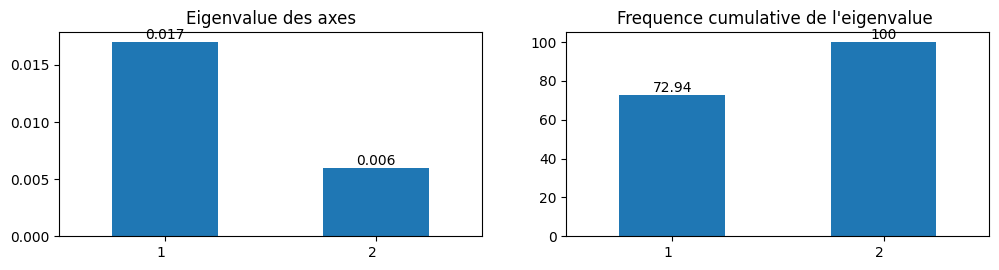

In [44]:
### Inertia (Phi-square - Eigenvalue):  0.108
cal.print_eigenvalue(afc)

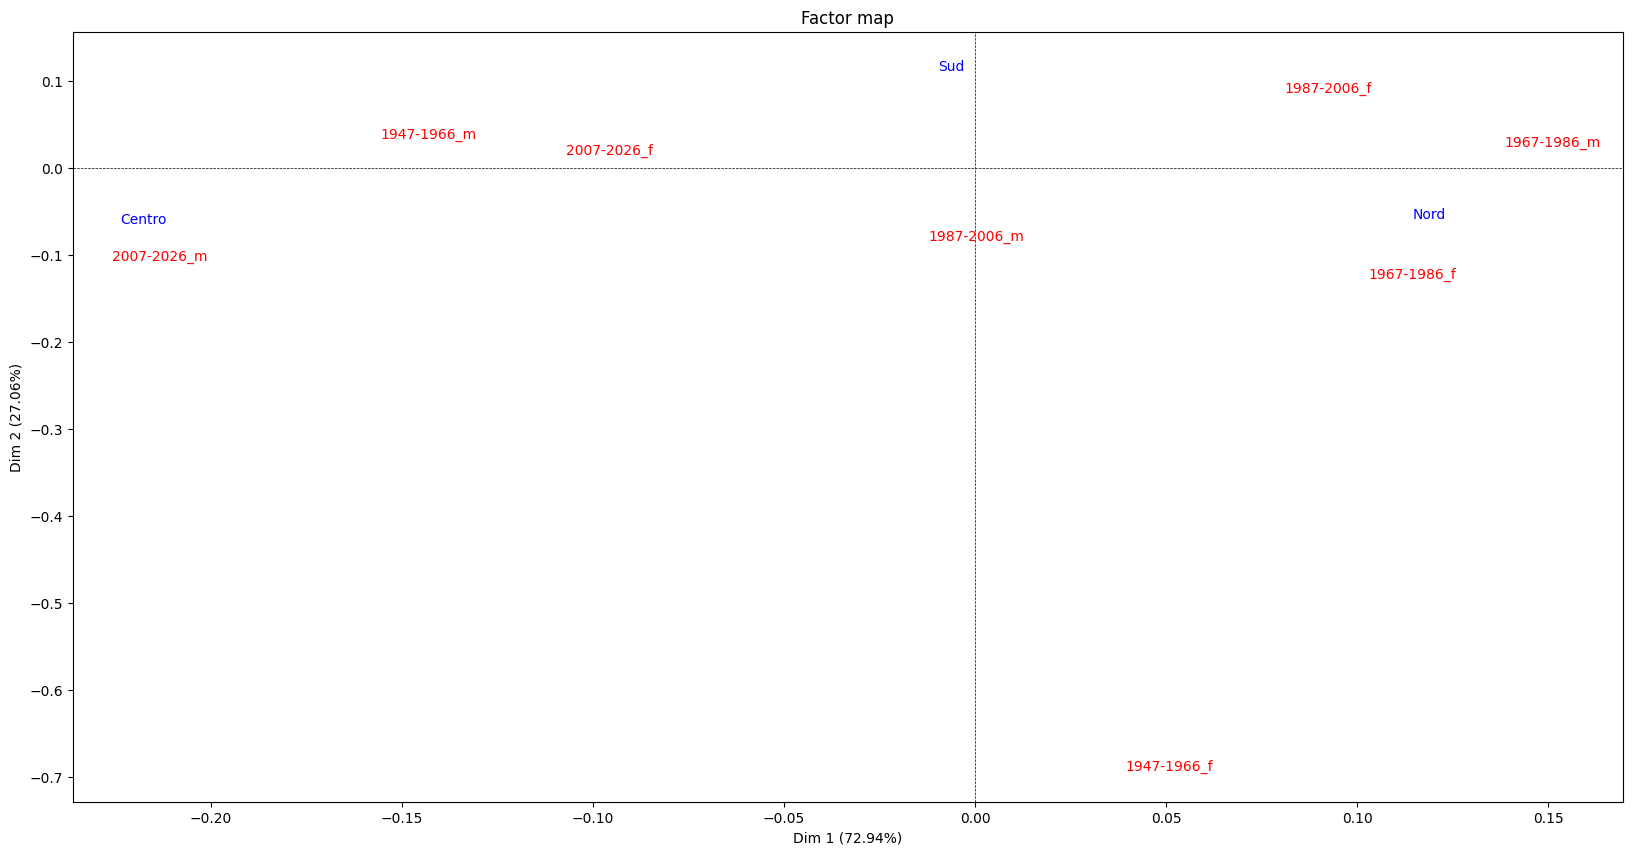

In [47]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(20,10))

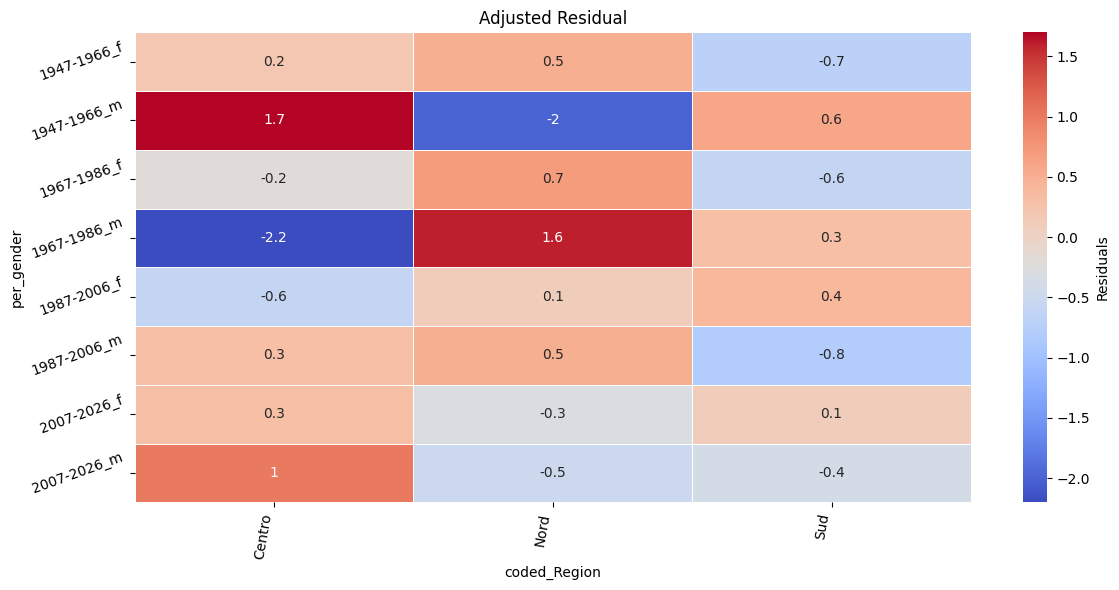

In [49]:
pp = bl.plot_chi2_residuals(observed, figsize=(12, 6))

In [50]:
### do not forget the number:
# proportionally more women but in mumber more men
observed


coded_Region,Centro,Nord,Sud
per_gender,,,
1947-1966_f,1,2,0
1947-1966_m,42,56,51
1967-1986_f,4,10,5
1967-1986_m,25,73,49
1987-2006_f,4,10,8
1987-2006_m,19,36,22
2007-2026_f,4,6,5
2007-2026_m,6,7,5


## Analyse countries and activity periods

In [51]:
### Inspect coded countries
print(df_p.groupby(by='coded_Region').size().sort_values(ascending=False))

coded_Region
Nord      257
Sud       177
Centro    127
dtype: int64


In [52]:
### Inspect activity periods
print(df_p.groupby(by='periodsActivity').size().sort_values(ascending=False))

periodsActivity
1967-1986    166
1947-1966    152
1987-2006     99
1927-1946     70
1907-1926     41
2007-2026     33
dtype: int64


In [53]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_country=pd.crosstab(df_p.periodsActivity, df_p.coded_Region, margins=True)

## display all columns
pd.set_option('display.max_columns', None)

per_vs_country

coded_Region,Centro,Nord,Sud,All
periodsActivity,,,,
1907-1926,8,22,11,41
1927-1946,14,35,21,70
1947-1966,43,58,51,152
1967-1986,29,83,54,166
1987-2006,23,46,30,99
2007-2026,10,13,10,33
All,127,257,177,561


In [54]:
observed = per_vs_country.iloc[2:-1, :-1 ]
observed

coded_Region,Centro,Nord,Sud
periodsActivity,,,
1947-1966,43,58,51
1967-1986,29,83,54
1987-2006,23,46,30
2007-2026,10,13,10


In [55]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [56]:
expected=bl.bivariate_stats(observed)

Chi-square : 7.76 , dof : 6
p-value : 0.256
Inertia (Phi-square):  0.017
Cramer:  0.093


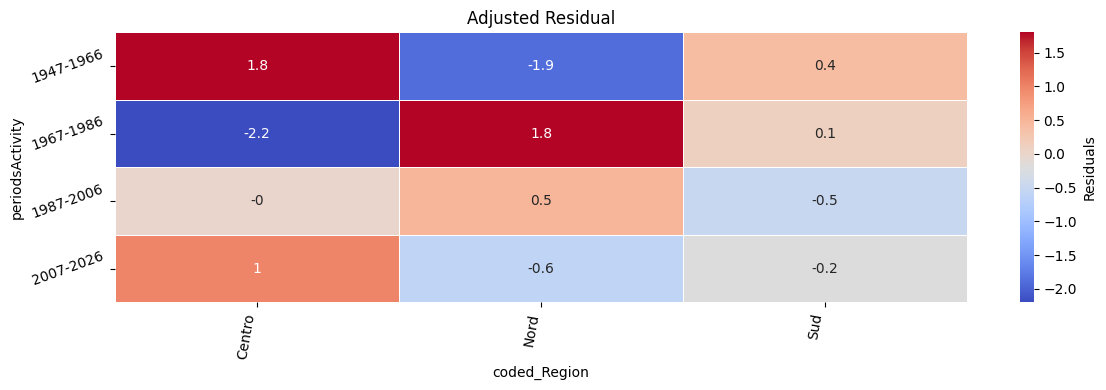

In [57]:
pp = bl.plot_chi2_residuals(observed, figsize=(12, 4))

### Inspect the number of individuals, the real distribution

In [58]:
observed_f = observed# .loc[:, [col for col in observed.columns if col not in ['professor']]]

In [59]:
observed_f=observed_f.reindex(sorted(observed_f.columns, reverse=True), axis=1)


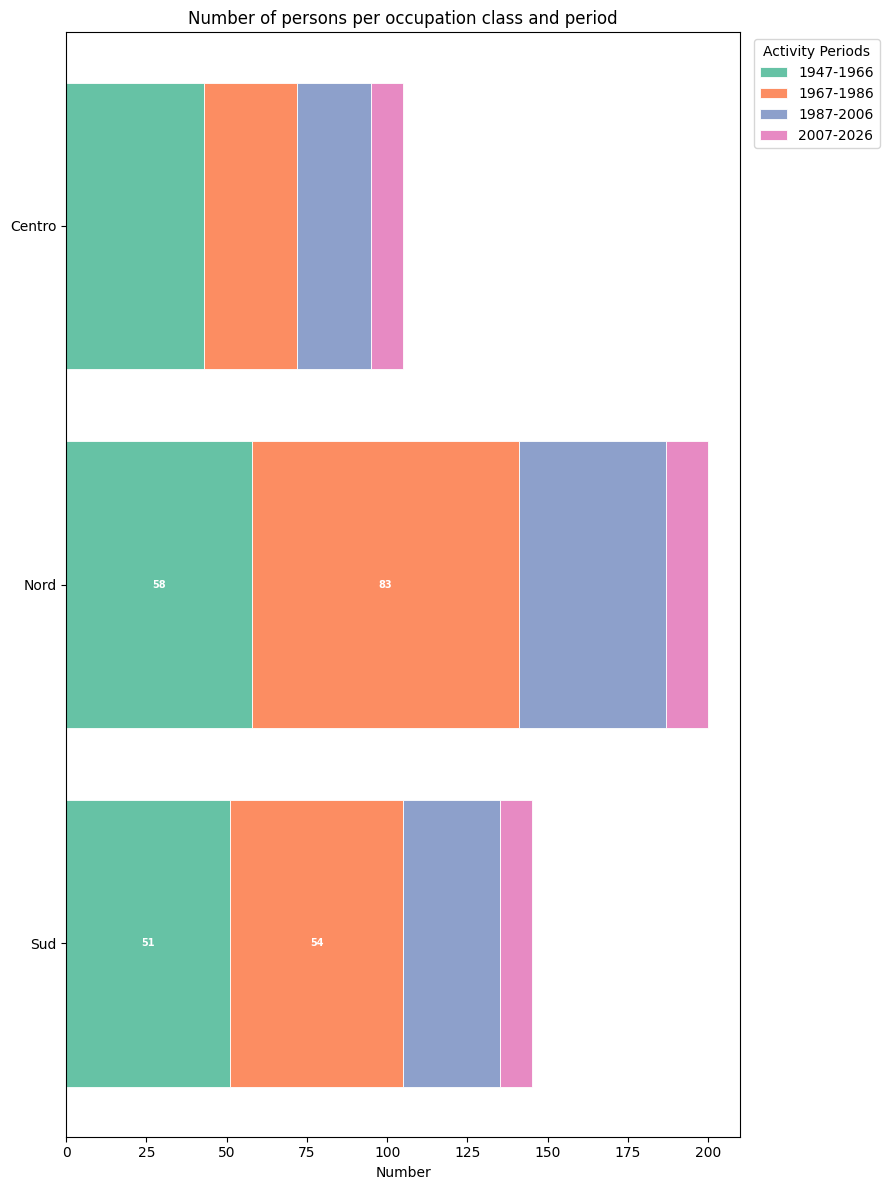

In [60]:

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 12))

colors = plt.cm.Set2.colors
lefts = np.zeros(len(observed_f.columns))  # horizontal accumulator

for i, (row_label, row_vals) in enumerate(observed_f.iterrows()):
    ax.barh(
        observed_f.columns,
        row_vals,
        left=lefts,
        color=colors[i % len(colors)],
        label=row_label,
        edgecolor='white',
        linewidth=0.6,
    )
    # Label inside each segment
    for j, (col, val) in enumerate(zip(observed_f.columns, row_vals)):
        if val > 50:
            ax.text(
                lefts[j] + val / 2, j,
                f'{int(val):,}',
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold'
            )
    lefts += row_vals.values

# --- Fix scientific notation ---
fmt = ScalarFormatter()
fmt.set_scientific(False)
fmt.set_useOffset(False)
ax.xaxis.set_major_formatter(fmt)  # x-axis now holds the counts



# --- Formatting ---
ax.set_xlabel('Number')
ax.set_title('Number of persons per occupation class and period', fontsize=12)
ax.legend(title='Activity Periods', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

### CA (correspondence analysis)

In [61]:
observed

coded_Region,Centro,Nord,Sud
periodsActivity,,,
1947-1966,43,58,51
1967-1986,29,83,54
1987-2006,23,46,30
2007-2026,10,13,10


In [62]:
# Initialise the CA object, then fit (=calculate)
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1947-...iodsActivity')
,col_labels,Index(['Centr...coded_Region')
,stats,True


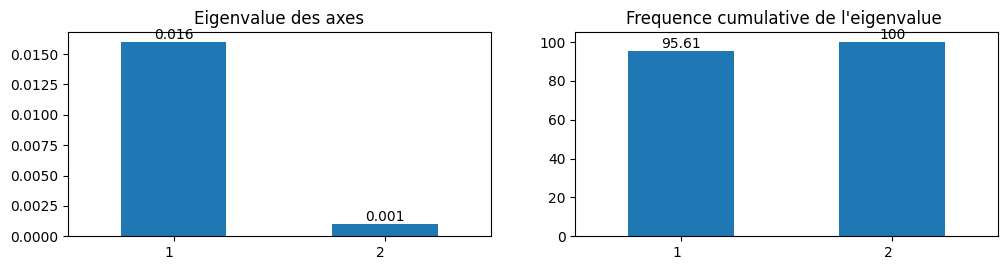

In [63]:
### Inertia (Phi-square):  0.085
cal.print_eigenvalue(afc)

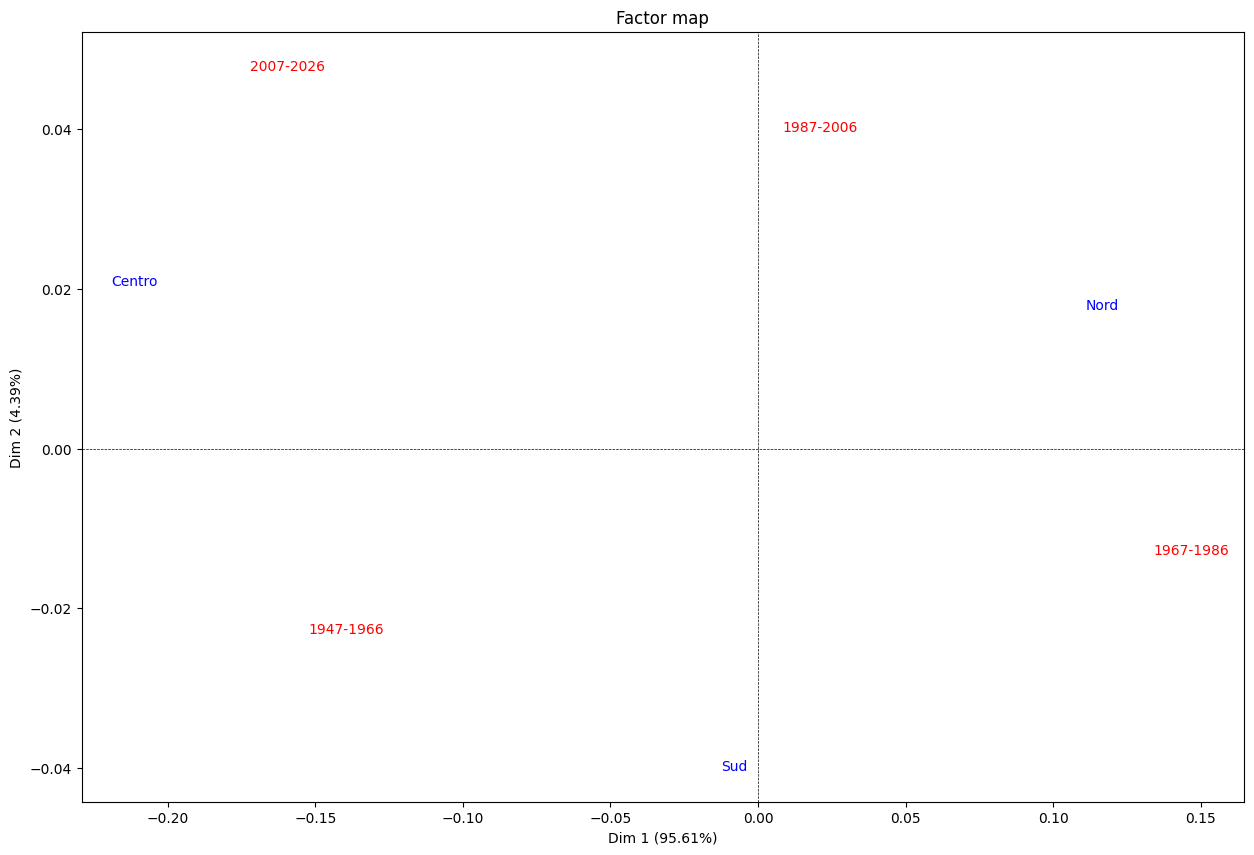

In [65]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(15,10))

On the third dimension we can notably observe the situation of Poland. Compare with Italy and France 

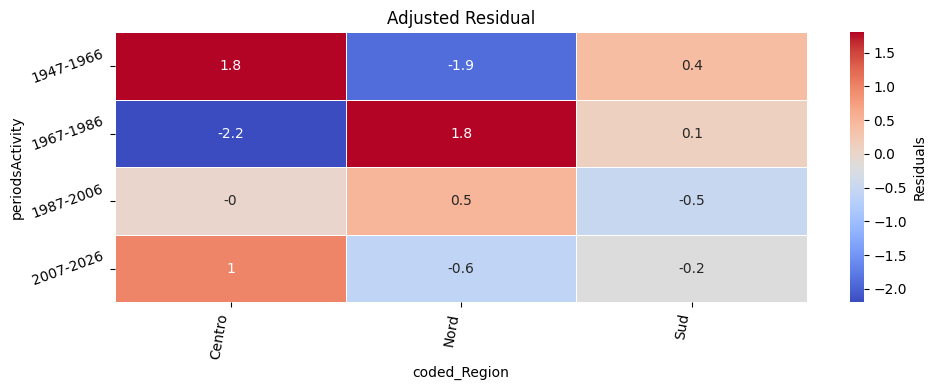

In [67]:
## Use the adjusted residual to test the interpretation
pp = bl.plot_chi2_residuals(observed, figsize=(10, 4))

## Occupation and field as additional qualitative variables

In [68]:
csv_address='da4-persons-feature.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None', 'NaN'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes
0,1,http://www.wikidata.org/entity/Q104599786,politico,professore-universitario,medico,NaN,indipendente,NaN,1,NaN
1,2,http://www.wikidata.org/entity/Q105296748,NaN,economista,banchiere,NaN,indipendente,NaN,2,NaN
2,3,http://www.wikidata.org/entity/Q105320865,NaN,professore-universitario,economista,NaN,indipendente,NaN,3,NaN
3,4,http://www.wikidata.org/entity/Q1053876,politico,avvocato,giornalista,NaN,Partito Repubblicano Italiano,NaN,4,NaN
4,5,http://www.wikidata.org/entity/Q1055104,politico,ingegnere,imprenditore,NaN,Forza Italia,NaN,5,NaN


In [69]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pk_person_features  576 non-null    int64  
 1   person_uri          576 non-null    object 
 2   occupation_main     567 non-null    object 
 3   occupation_sec1     380 non-null    object 
 4   occupation_sec2     183 non-null    object 
 5   party_main          0 non-null      float64
 6   party_sec1          576 non-null    object 
 7   party_sec2          91 non-null     object 
 8   fk_person           576 non-null    int64  
 9   notes               0 non-null      float64
dtypes: float64(2), int64(2), object(6)
memory usage: 45.1+ KB


In [70]:
df_p = pd.merge(df_p,df_pfeat, on='person_uri', how='left')

In [71]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   person_uri          561 non-null    object 
 1   labelPer            559 non-null    object 
 2   birthYear           561 non-null    float64
 3   gender              561 non-null    object 
 4   labelPlace          561 non-null    object 
 5   geometry            561 non-null    object 
 6   uriPlace            561 non-null    object 
 7   periods             561 non-null    object 
 8   index_right         561 non-null    float64
 9   reg_name            561 non-null    object 
 10  reg_istat_code_num  561 non-null    float64
 11  reg_istat_code      561 non-null    float64
 12  coded_Region        561 non-null    object 
 13  activityYear        561 non-null    float64
 14  periodsActivity     561 non-null    object 
 15  per_gender          562 non-null    object 
 16  pk_perso

In [72]:
df_p.iloc[50:54]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes
50,http://www.wikidata.org/entity/Q3608581,Alberto Simonini,1896.0,maschio,Reggio Emilia,POINT (10.633333 44.7),http://www.wikidata.org/entity/Q13360,1891-1900,7.0,Emilia-Romagna,8.0,8.0,Nord,1931.0,1927-1946,1927-1946_m,197.0,politico,NaN,NaN,NaN,Partito Socialista Democratico Italiano,NaN,197.0,NaN
51,http://www.wikidata.org/entity/Q1370804,Piero Malvestiti,1899.0,maschio,Apiro,POINT (13.13027 43.393064),http://www.wikidata.org/entity/Q73249,1891-1900,10.0,Marche,11.0,11.0,Centro,1934.0,1927-1946,1927-1946_m,51.0,politico,giornalista,NaN,NaN,Democrazia Cristiana,NaN,51.0,NaN
52,http://www.wikidata.org/entity/Q3659021,Carlo Arnaudi,1899.0,maschio,Torino,POINT (7.676111 45.079167),http://www.wikidata.org/entity/Q495,1891-1900,0.0,Piemonte,1.0,1.0,Nord,1934.0,1927-1946,1927-1946_m,226.0,politico,insegnante,NaN,NaN,Partito Socialista Italiano,NaN,226.0,NaN
53,http://www.wikidata.org/entity/Q3852926,Mauro Scoccimarro,1895.0,maschio,Udine,POINT (13.233333 46.066667),http://www.wikidata.org/entity/Q2790,1891-1900,5.0,Friuli-Venezia Giulia,6.0,6.0,Nord,1930.0,1927-1946,1927-1946_m,385.0,politico,partigiano,NaN,NaN,Partito Comunista Italiano,NaN,385.0,NaN


In [73]:
### missing values are excluded by default
# To keep them add parameter , dropna=False
df_p.groupby(by='occupation_main', dropna=False).size()


occupation_main
politico    552
NaN          10
dtype: int64

## Country vs main occupation

In [74]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
occupation_vs_country=pd.crosstab(df_p.occupation_main, df_p.coded_Region, margins=True)

occupation_vs_country

coded_Region,Centro,Nord,Sud,All
occupation_main,,,,
politico,125,252,175,552
All,125,252,175,552


In [75]:
observed = occupation_vs_country.iloc[:-1, :-1 ]

In [76]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [77]:
print(type(observed))
print(observed)

<class 'pandas.core.frame.DataFrame'>
coded_Region     Centro  Nord  Sud
occupation_main                   
politico            125   252  175


In [ ]:
# 1. Creiamo una copia per non rovinare il dataset originale
df_analysis = DActives.copy()

# 2. Riempiamo i NaN nella colonna occupation_main con "Non dichiarato"
df_analysis['occupation_main'] = df_analysis['occupation_main'].fillna("Non dichiarato")

# 3. Filtriamo per tenere SOLO i "politico" e i "Non dichiarato"
mask = df_analysis['occupation_main'].isin(['politico', 'Non dichiarato'])
df_filtered = df_analysis[mask]

# 4. Creiamo la tabella di contingenza
observed = pd.crosstab(df_filtered['occupation_main'], df_filtered['coded_Region'])

print(observed) # Ora vedrai due righe: 'politico' e 'Non dichiarato'

In [ ]:
from scipy.stats import chisquare

# I dati reali (i numeri che hai postato tu)
osservati = observed.values.flatten()

# Esegui il test
stat, p_value = chisquare(osservati)

print(f"Statistica Chi-quadrato: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusione: La distribuzione non è uniforme (ci sono differenze significative tra regioni).")
else:
    print("Conclusione: Non ci sono prove di una distribuzione non uniforme.")

### CA

In [ ]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

In [ ]:
# One only dimension represents the whole inertia/variance
cal.print_eigenvalue(afc)

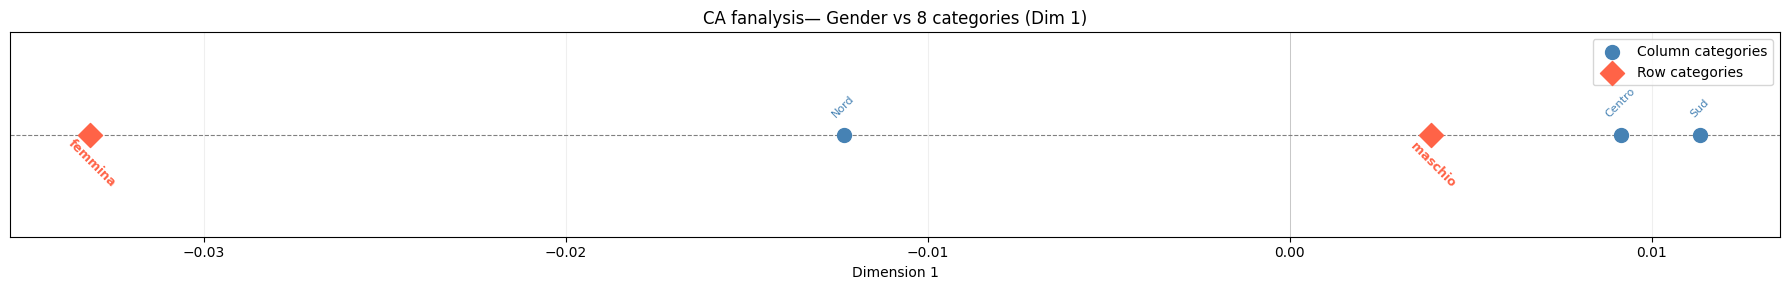

<Figure size 640x480 with 0 Axes>

In [80]:

# Usage with fanalysis
cal.plot_ca_single_axis(row_coords_fan, col_coords_fan,
                    title="CA fanalysis— Gender vs 8 categories (Dim 1)")



## Period vs main occupation

In [82]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


### CA

In [84]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['polit...upation_main')
,col_labels,Index(['Centr...coded_Region')
,stats,True


In [86]:
###  fanalysis coord.

row_coords_fan = pd.DataFrame(afc.row_coord_,
                               index=observed.index,
                               columns=[f"Dim{i+1}" for i in range(afc.row_coord_.shape[1])])

col_coords_fan = pd.DataFrame(afc.col_coord_,
                               index=observed.columns,
                               columns=[f"Dim{i+1}" for i in range(afc.col_coord_.shape[1])])


## Period and country vs main occupation

In [89]:
### Apply function and create new column
df_p['per_occupation']= df_p.apply(lambda x: np.nan if pd.isna(x.occupation_main) \
                              else x.periodsActivity +'_'+ x.occupation_main, axis=1)

In [90]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,per_occupation
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,1907-1926_m,355.0,politico,sindacalista,NaN,NaN,Partito Socialista Italiano,NaN,355.0,NaN,1907-1926_politico
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,1907-1926_m,461.0,politico,diplomatico,NaN,NaN,Partito Repubblicano Italiano,NaN,461.0,NaN,1907-1926_politico


In [91]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_occ_vs_country=pd.crosstab(df_p.per_occupation, df_p.coded_Region, margins=True)
per_occ_vs_country

coded_Region,Centro,Nord,Sud,All
per_occupation,,,,
1907-1926_politico,8,22,11,41
1927-1946_politico,14,35,21,70
1947-1966_politico,43,58,51,152
1967-1986_politico,29,82,54,165
1987-2006_politico,22,42,28,92
2007-2026_politico,9,13,10,32
All,125,252,175,552


In [92]:
observed = per_occ_vs_country.iloc[:-1, :-1 ]

In [93]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [94]:
expected=bl.bivariate_stats(observed)

Chi-square : 9.04 , dof : 10
p-value : 0.529
Inertia (Phi-square):  0.016
Cramer:  0.09


### CA

In [95]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1907-...r_occupation')
,col_labels,Index(['Centr...coded_Region')
,stats,True


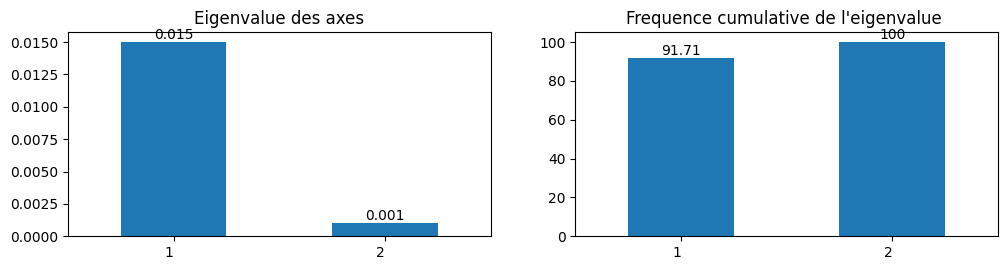

In [96]:
### Inertia (Phi-square - Eigenvalue):  0.083
cal.print_eigenvalue(afc)

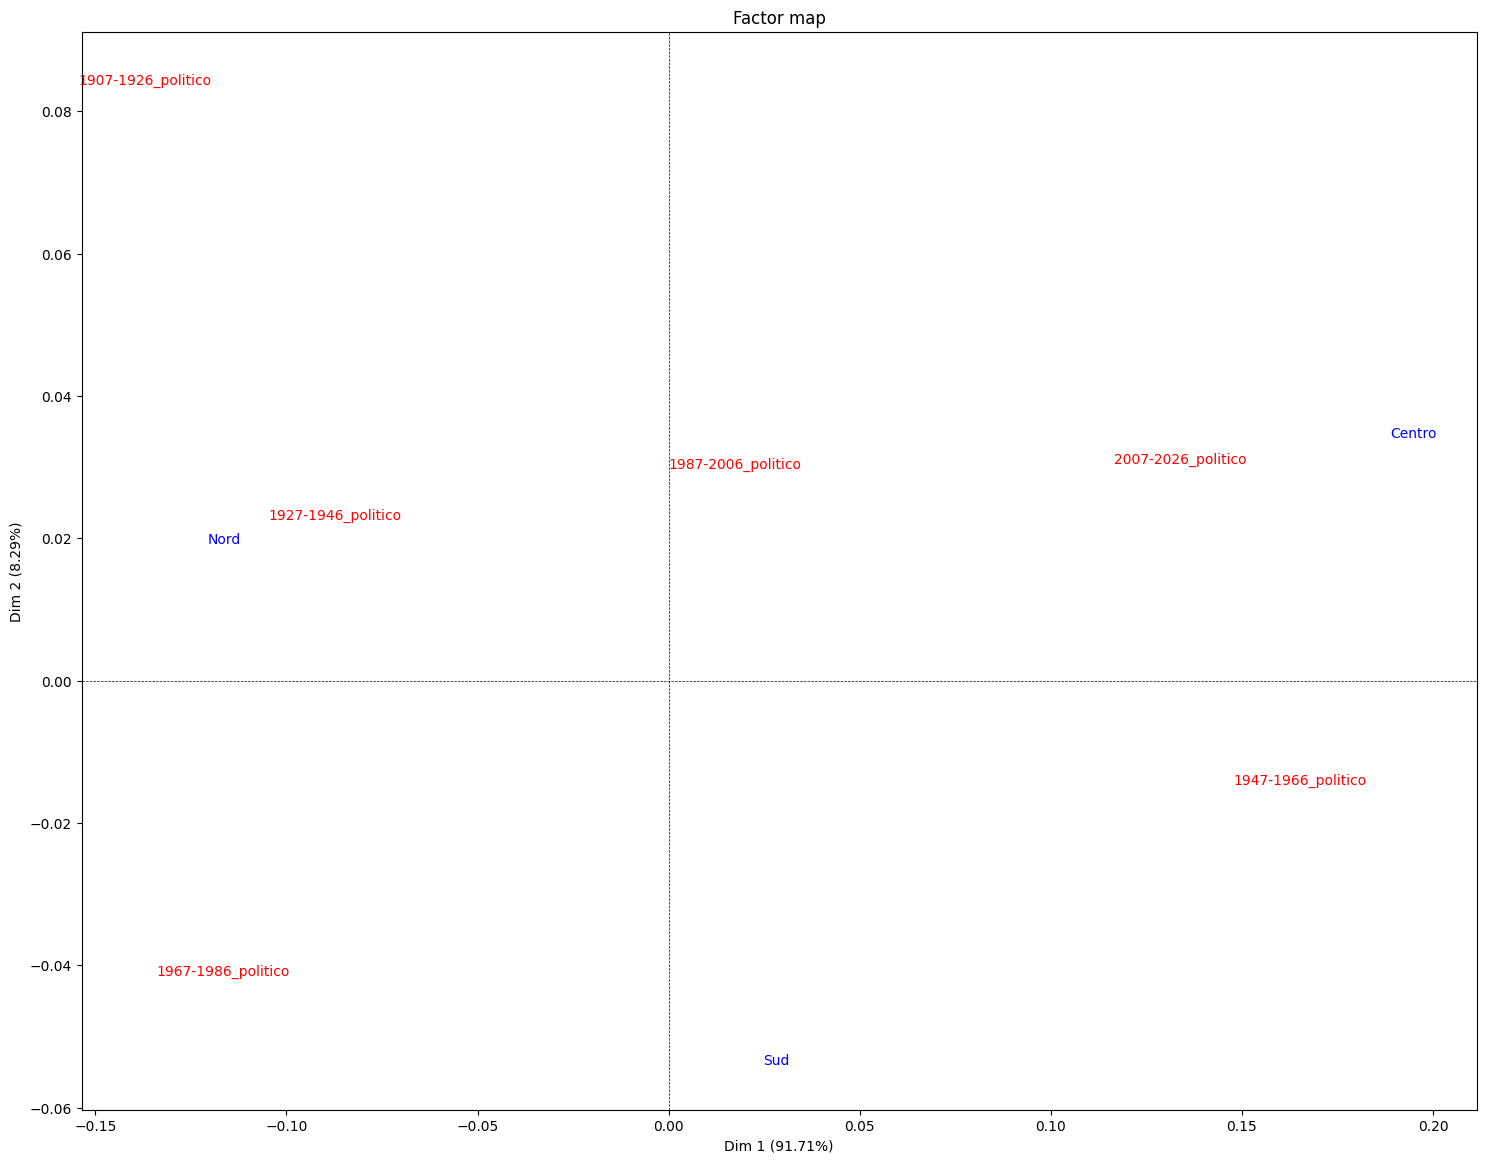

In [98]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(18,14))

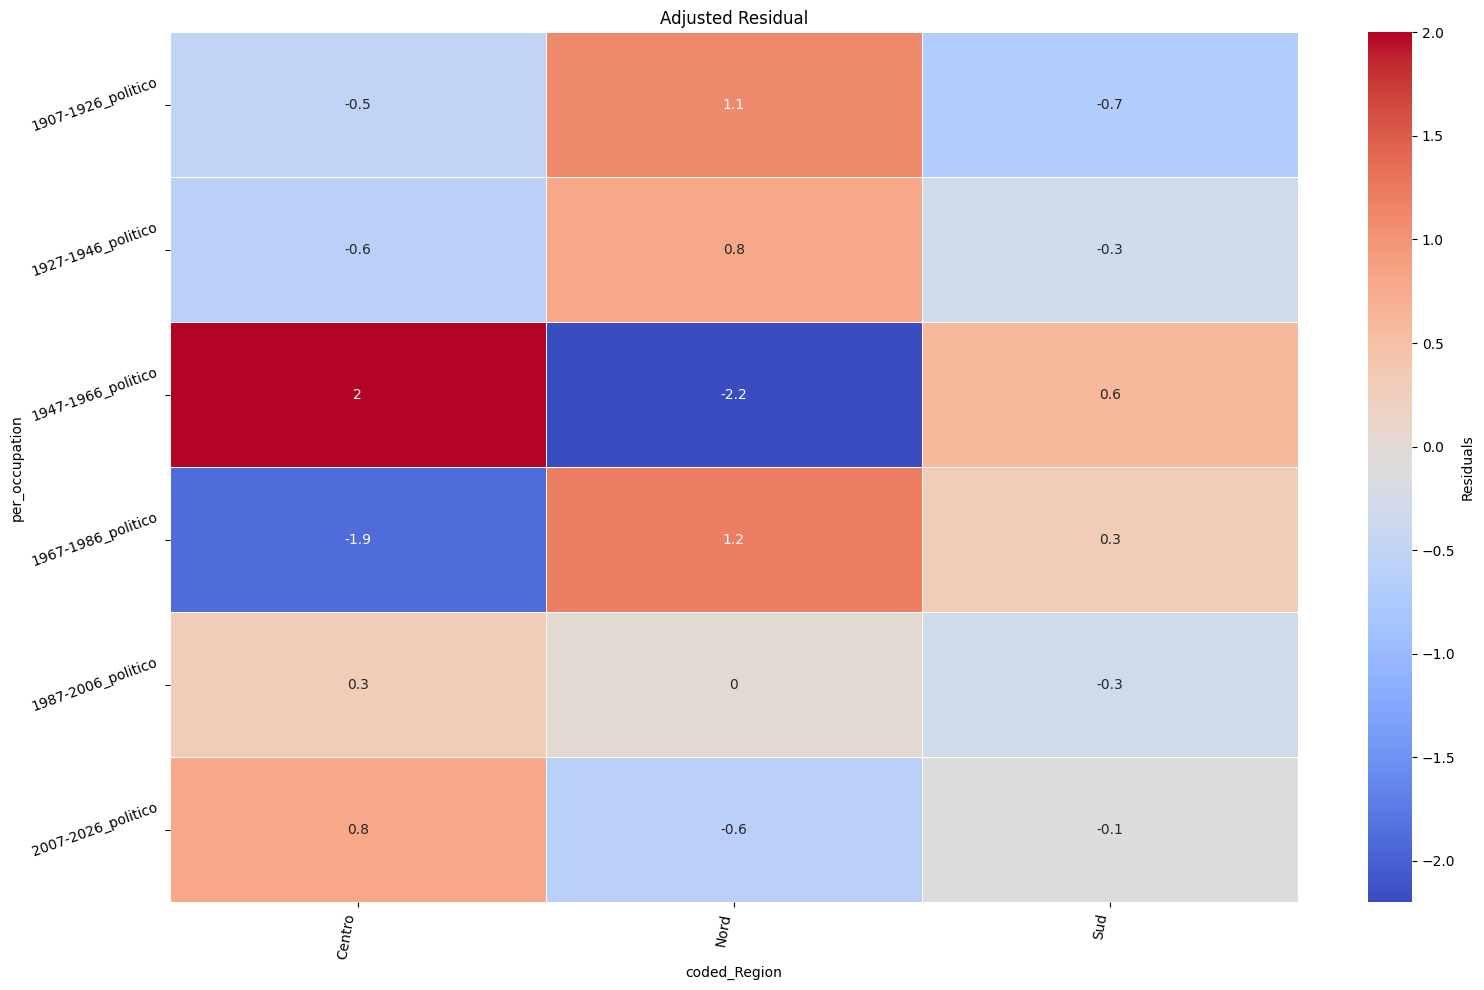

In [100]:
pp = bl.plot_chi2_residuals(observed, figsize=(16, 10))

## Gender and main occupation vs period

In [101]:
### Apply function and create new column
df_p['occup_gen']= df_p.apply(lambda x: np.nan if pd.isna(x.occupation_main) \
                              else x.occupation_main +'_'+ code_gender(x.gender), axis=1)

In [102]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,per_occupation,occup_gen
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,1907-1926_m,355.0,politico,sindacalista,NaN,NaN,Partito Socialista Italiano,NaN,355.0,NaN,1907-1926_politico,politico_m
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,1907-1926_m,461.0,politico,diplomatico,NaN,NaN,Partito Repubblicano Italiano,NaN,461.0,NaN,1907-1926_politico,politico_m


In [103]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_occGen=pd.crosstab(df_p.periodsActivity, df_p.occup_gen, margins=True)
per_vs_occGen

occup_gen,politico_f,politico_m,All
periodsActivity,,,
1907-1926,0,41,41
1927-1946,0,70,70
1947-1966,3,149,152
1967-1986,19,146,165
1987-2006,20,72,92
2007-2026,15,17,32
All,57,495,552


In [104]:
observed = per_vs_occGen.iloc[:-1, :-1 ]

In [105]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [106]:
expected=bl.bivariate_stats(observed)

Chi-square : 83.59 , dof : 5
p-value : 0.0
Inertia (Phi-square):  0.151
Cramer:  0.389


### CA

In [107]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1907-...iodsActivity')
,col_labels,Index(['polit...e='occup_gen')
,stats,True


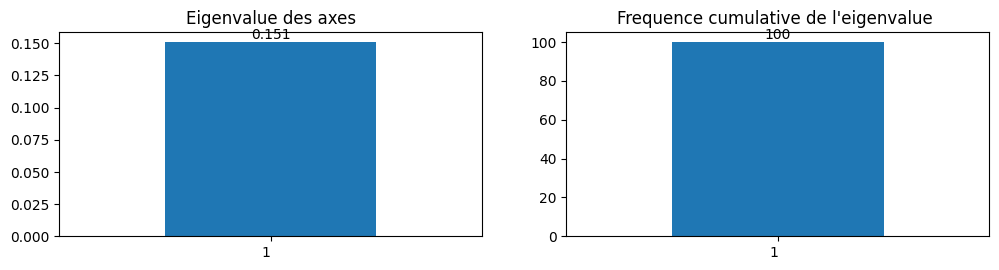

In [108]:
### Inertia (Phi-square - Eigenvalue):  0.083
cal.print_eigenvalue(afc)

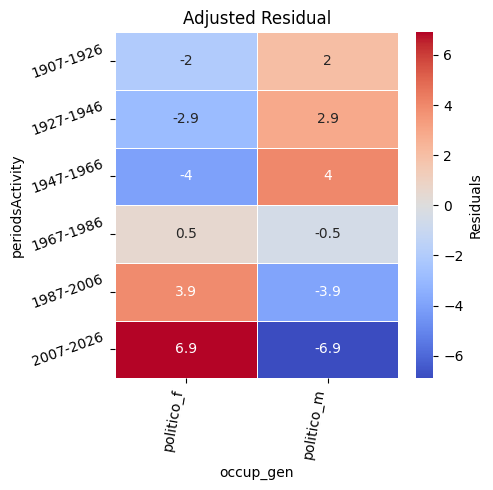

In [110]:
pp = bl.plot_chi2_residuals(observed, figsize=(5, 5))

#### Comment
Apparently, the gender distribution follows the general evolution of disciplines and genders, with a specific interest of female scientists for physics

## Political Party

In [111]:
### Inspect secondary occupations
print(df_p.groupby(by='party_sec1').size().sort_values(ascending=False).iloc[:200])

party_sec1
Democrazia Cristiana                               180
indipendente                                        73
Partito Democratico                                 64
Partito Socialista Italiano                         46
Forza Italia                                        31
Partito Socialista Democratico Italiano             22
Partito Liberale Italiano                           20
Lega Nord                                           18
Partito Repubblicano Italiano                       16
Movimento 5 Stelle                                  14
Partito Comunista Italiano                          12
Alleanza Nazionale                                   9
Il Popolo della Libertà                              9
Fratelli d'Italia                                    7
Scelta Civica                                        6
Partito d'Azione                                     4
Partito Popolare Italiano                            4
Italia Viva                                          4

In [112]:
### We define a function that codes and aggregates the values in order to avoid dispersion

def codeSecparty(party: str):
    if 'Partito Democratico' in party \
        or 'Centro Democratico' in party \
        or 'Partito Democratico del Lavoro' in party \
        or 'Partito Socialista Italiano' in party \
        or 'Partito Socialista Democratico Italiano' in party \
        or 'Partito Repubblicano Italiano' in party\
        or 'Democratici di Sinistra' in party \
        or 'Partito Comunista Italiano' in party \
        or "Partito d'Azione" in party \
        or "Federazione dei Verdi" in party \
        or "L'Ulivo" in party \
        or 'Partito Radicale' in party \
        or 'Rosa nel Pugno' in party \
        or 'Partito della Rifondazione Comunista' in party \
        or 'Partito Socialista Italiano di Unità Proletaria' in party \
        or 'sinistra indipendente' in party :
        output='Sinistra/Centro Sinistra'
    elif 'Forza Italia' in party \
        or 'Partito Liberale Italiano' in party \
        or 'Lega Nord' in party \
        or 'Alleanza Nazionale' in party \
        or 'Il Popolo della Libertà' in party \
        or "Fratelli d'Italia" in party \
        or 'Alternativa Popolare' in party \
        or 'Nuovo Centrodestra' in party \
        or 'Identità e Azione' in party :
        output='Destra/Centro Destra'
    elif 'Movimento 5 Stelle' in party \
        or 'Democrazia Cristiana' in party \
        or 'Scelta Civica' in party \
        or 'Partito Popolare Italiano' in party \
        or 'Italia Viva' in party \
        or 'Unione di Centro (2002)' in party \
        or 'Centro Democratico' in party \
        or 'Italia dei Valori' in party \
        or 'Movimento Sociale Italiano' in party \
        or 'Partito Nazionale Fascista' in party :
        output='Centro'
    else:
        output=party
    return output

In [113]:
df_p['codedSecparty']=df_p.apply(lambda x : np.nan if pd.isna(x.party_sec1) \
                              else codeSecparty(x.party_sec1), axis=1)

In [114]:
### Inspect secondary occupations
dfca = df_p.groupby(by='codedSecparty').size().sort_values(ascending=False)

In [115]:
print(dfca.iloc[:14])

codedSecparty
Centro                      214
Sinistra/Centro Sinistra    176
Destra/Centro Destra         98
indipendente                 73
dtype: int64


In [116]:
lc=dfca.iloc[:14].index.to_list()
print(lc)

['Centro', 'Sinistra/Centro Sinistra', 'Destra/Centro Destra', 'indipendente']


## Political Party vs country

In [117]:
### Contingency table: 
dfc = df_p[df_p.codedSecparty.isin(lc)]
occ_vs_country=pd.crosstab(dfc.coded_Region, dfc.codedSecparty, margins=True)
occ_vs_country

codedSecparty,Centro,Destra/Centro Destra,Sinistra/Centro Sinistra,indipendente,All
coded_Region,,,,,
Centro,46,16,51,14,127
Nord,90,56,76,35,257
Sud,78,26,49,24,177
All,214,98,176,73,561


In [118]:
observed = occ_vs_country.iloc[:-1, :-1 ]

In [119]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [120]:
expected=bl.bivariate_stats(observed)

Chi-square : 12.32 , dof : 6
p-value : 0.055
Inertia (Phi-square):  0.022
Cramer:  0.105


### CA

In [121]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['Centr...coded_Region')
,col_labels,Index(['Centr...odedSecparty')
,stats,True


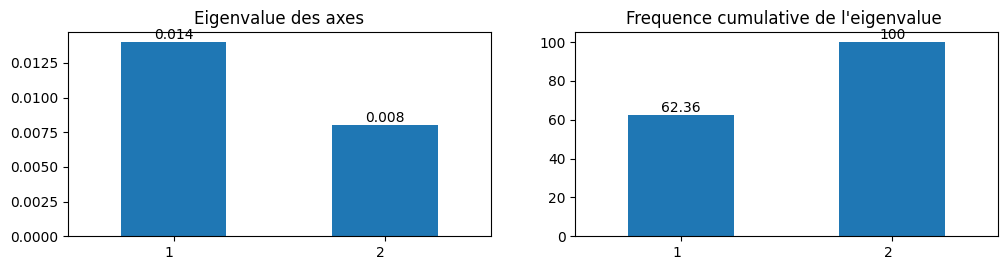

In [122]:
### Inertia (Phi-square - Eigenvalue):  0.083
cal.print_eigenvalue(afc)

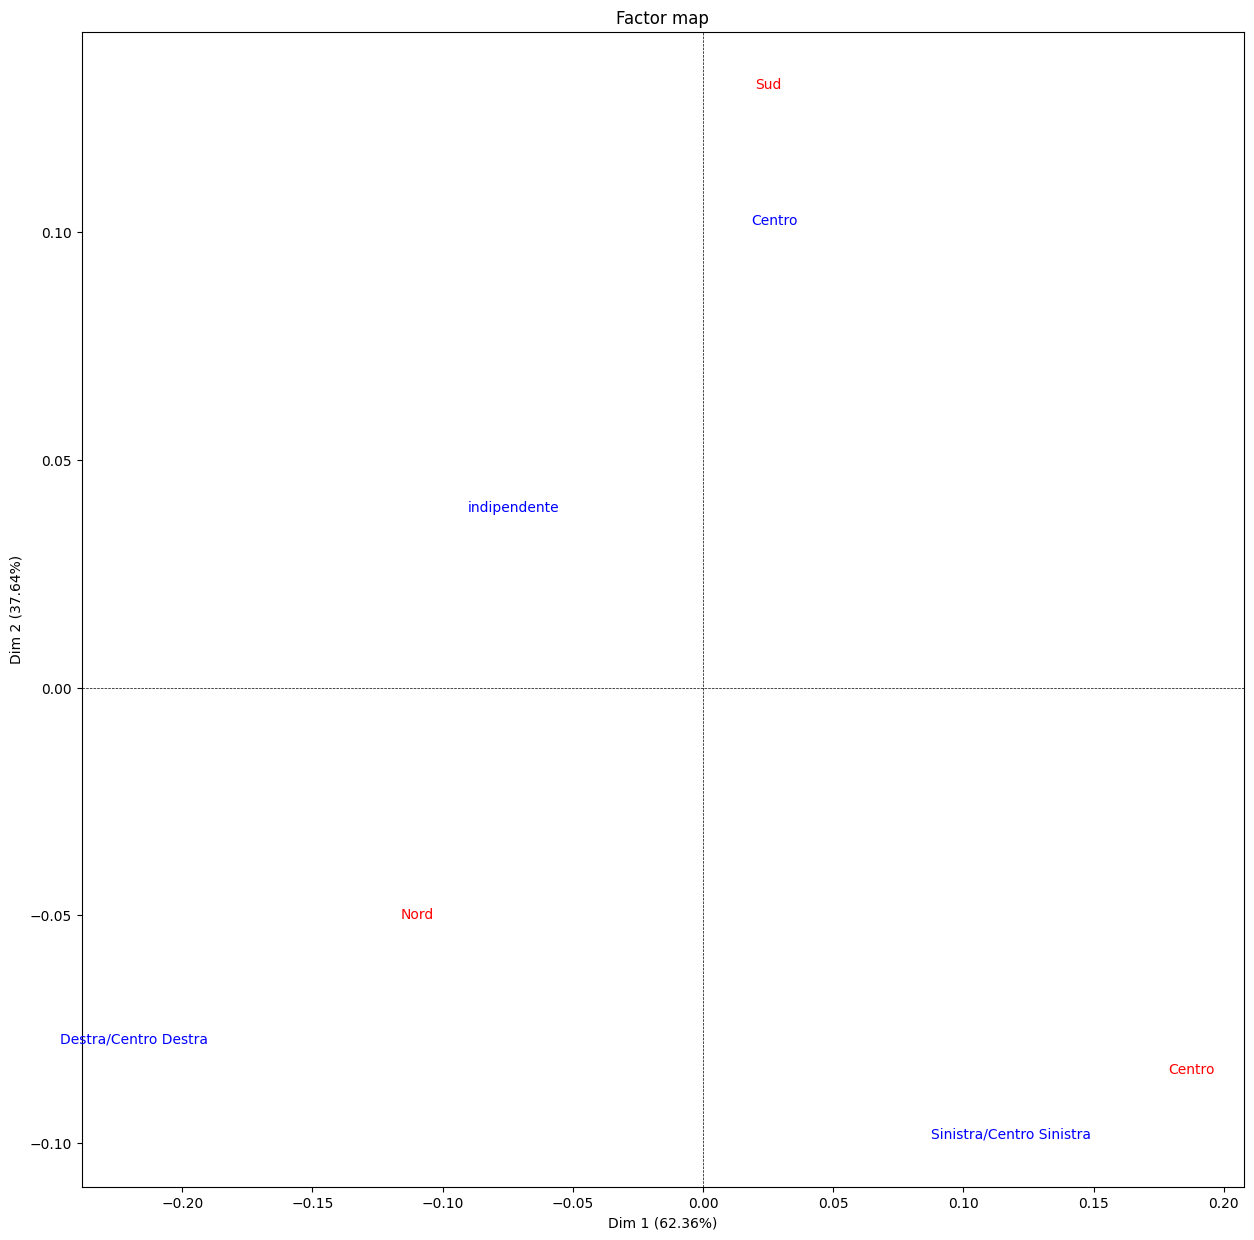

In [124]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(15,15))

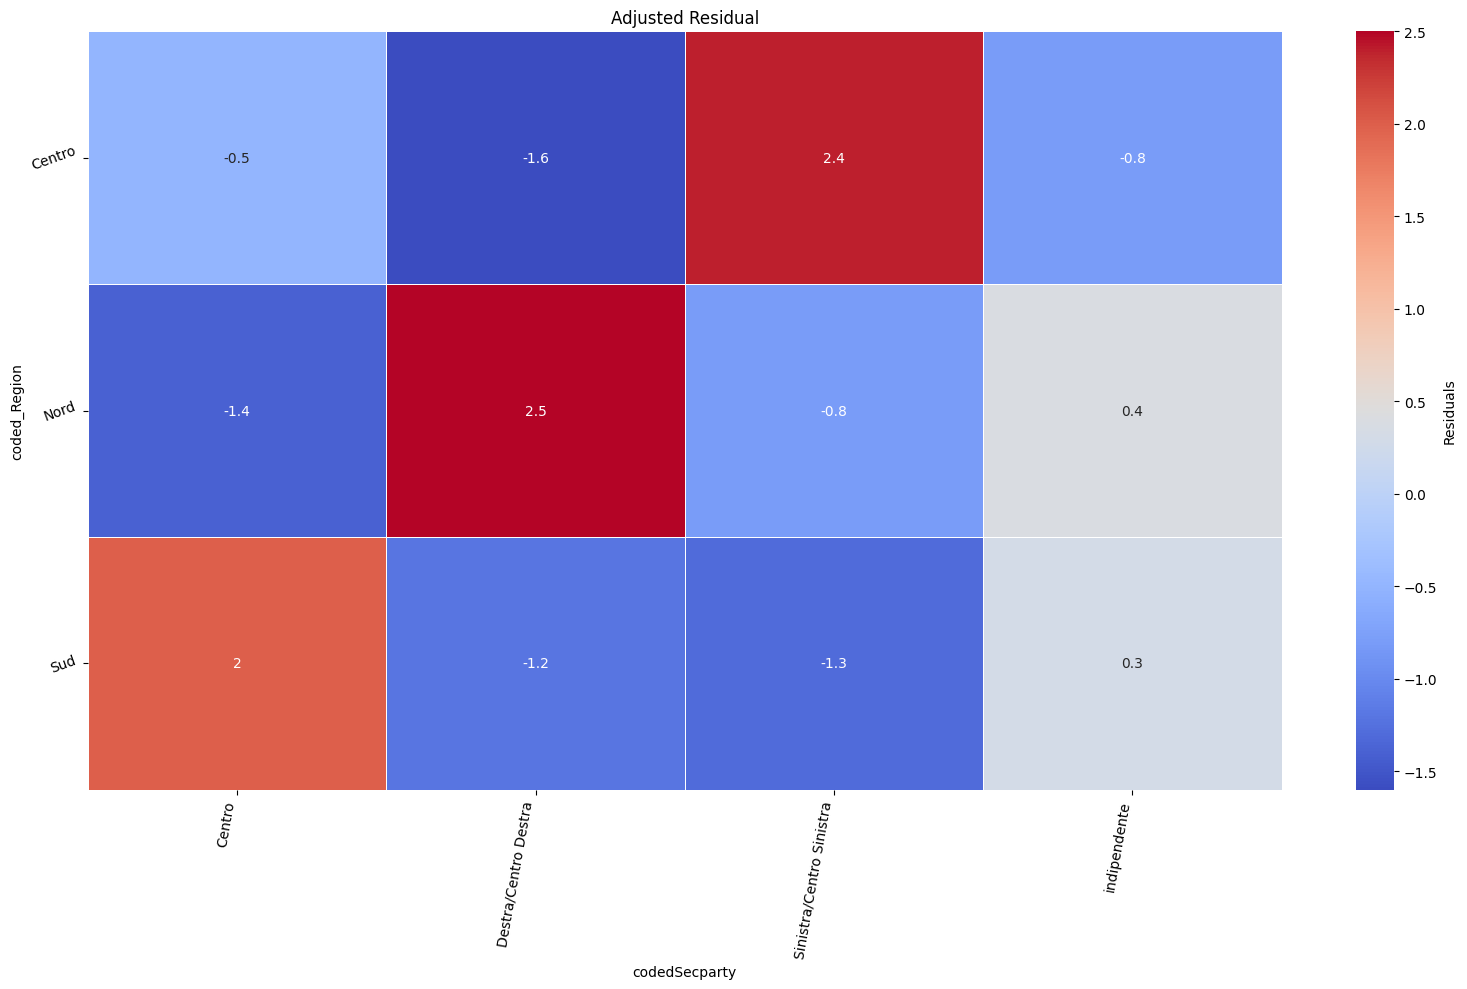

In [126]:
pp = bl.plot_chi2_residuals(observed, figsize=(16, 10))

## Secondary occupation vs period

In [127]:
### Contingency table: 
dfc = df_p[df_p.codedSecparty.isin(lc)]
occ_vs_per=pd.crosstab(dfc.periodsActivity, dfc.codedSecparty, margins=True)
occ_vs_per

codedSecparty,Centro,Destra/Centro Destra,Sinistra/Centro Sinistra,indipendente,All
periodsActivity,,,,,
1907-1926,21,6,10,4,41
1927-1946,44,6,19,1,70
1947-1966,83,8,50,11,152
1967-1986,34,34,65,33,166
1987-2006,18,36,24,21,99
2007-2026,14,8,8,3,33
All,214,98,176,73,561


In [128]:
observed = occ_vs_per.iloc[:-1, :-1 ]

In [129]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [130]:
expected=bl.bivariate_stats(observed)

Chi-square : 115.67 , dof : 15
p-value : 0.0
Inertia (Phi-square):  0.206
Cramer:  0.262


### CA

In [131]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1907-...iodsActivity')
,col_labels,Index(['Centr...odedSecparty')
,stats,True


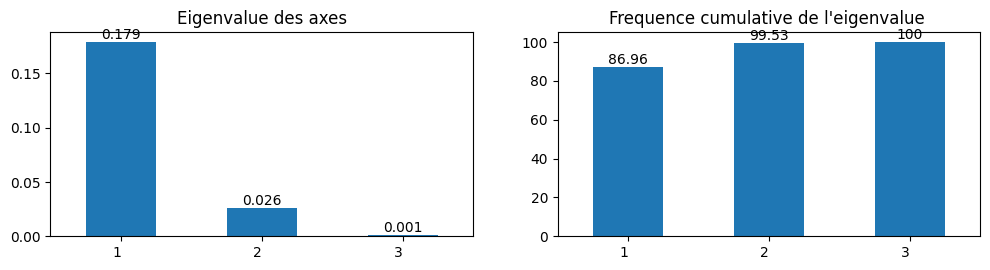

In [132]:
### Inertia (Phi-square - Eigenvalue):  0.083
cal.print_eigenvalue(afc)

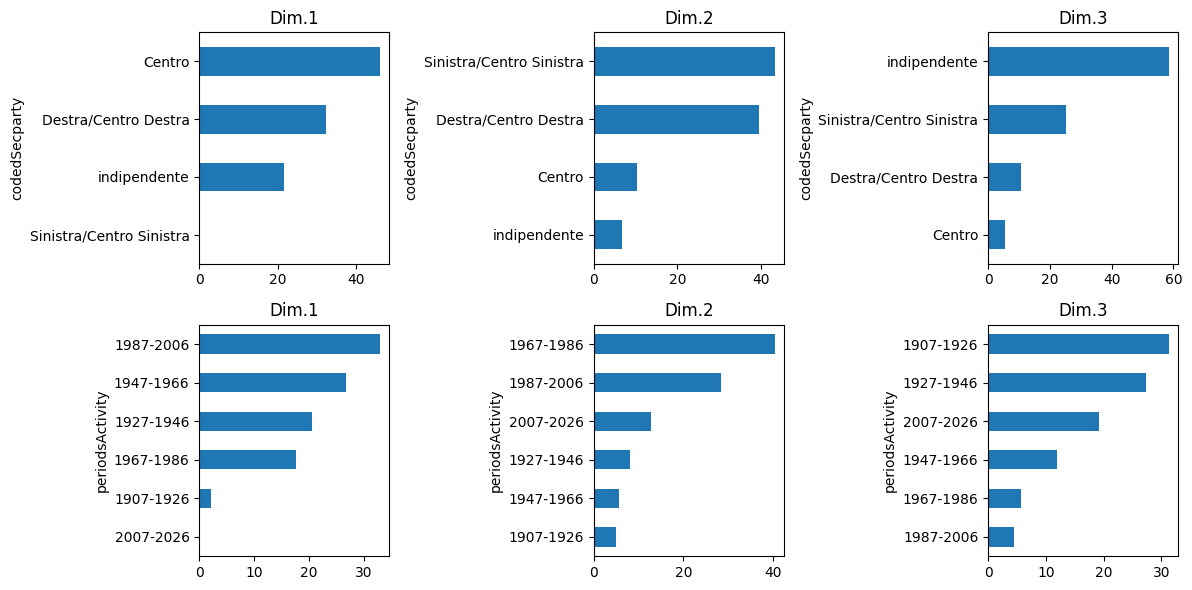

In [133]:
cal.dim_contributions(afc)

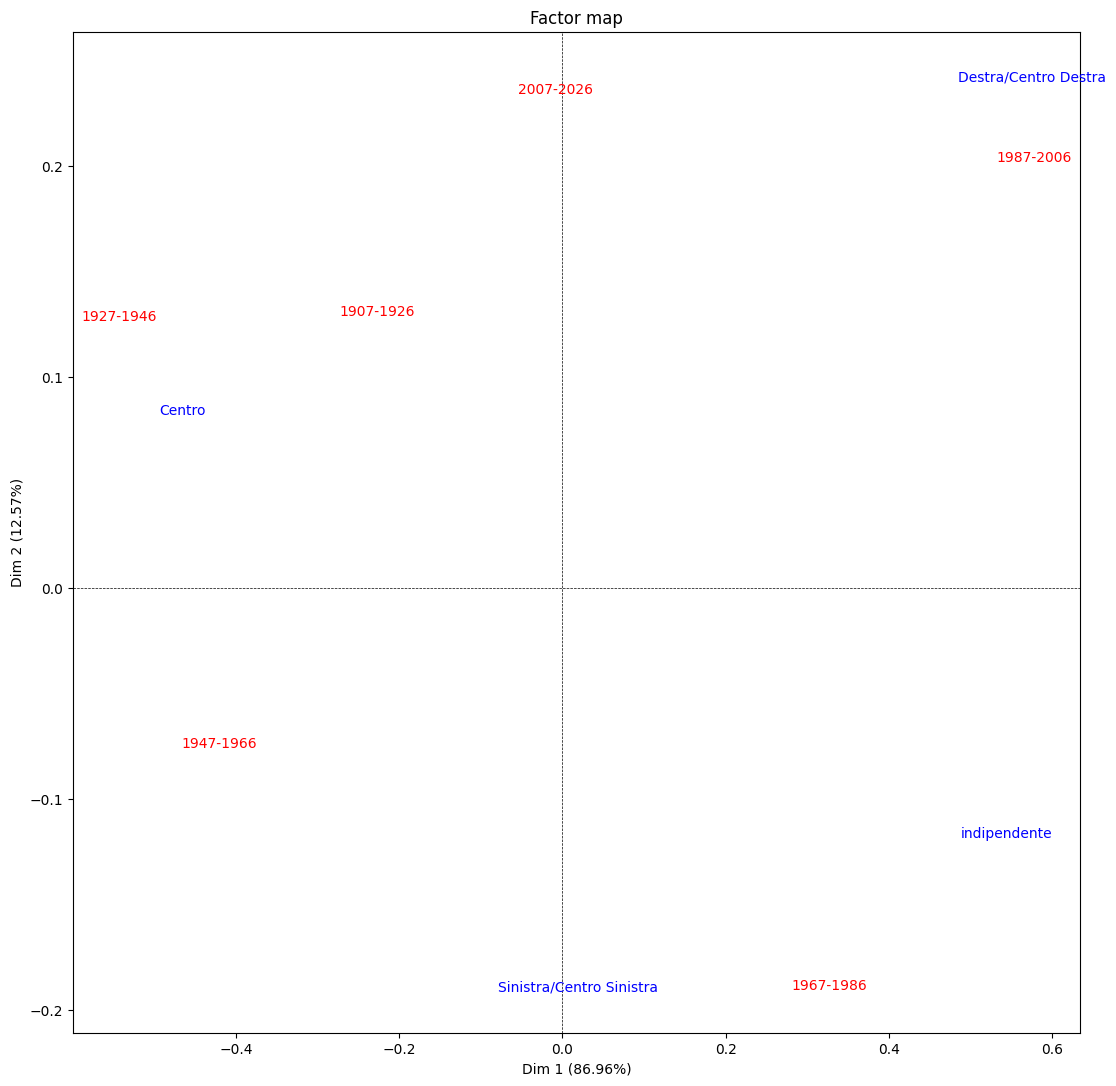

In [134]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(13,13))

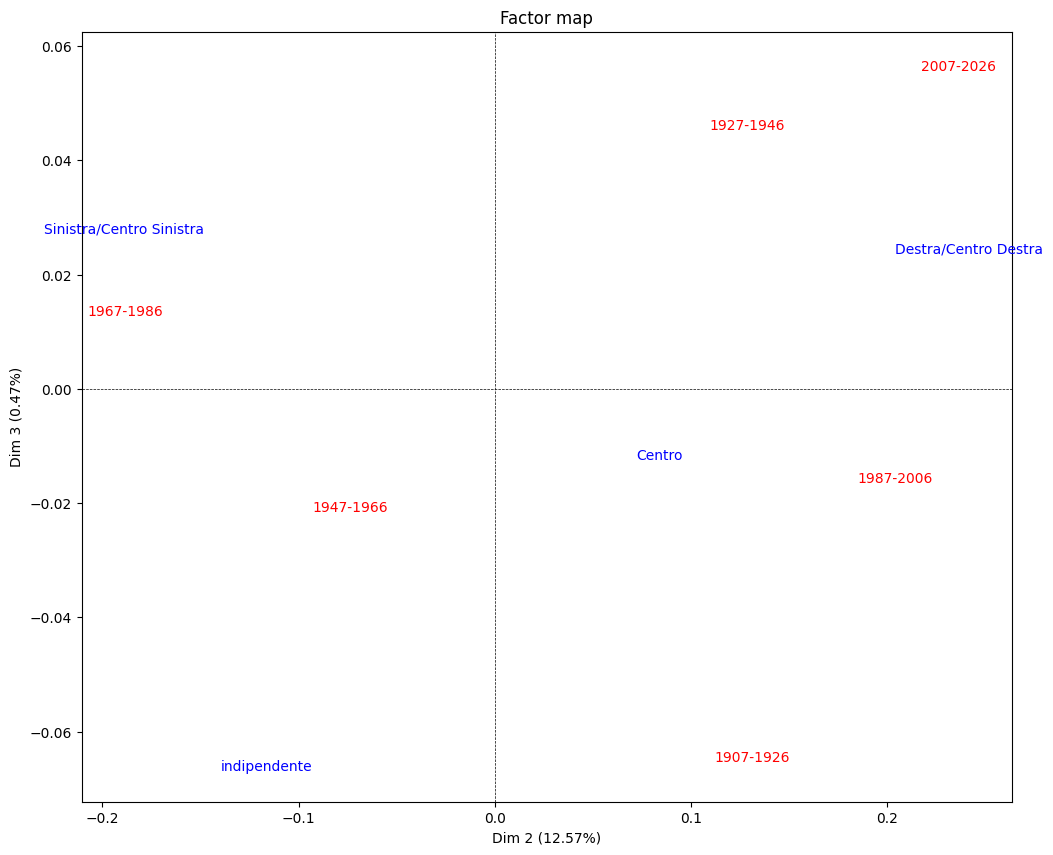

In [135]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(12,10))

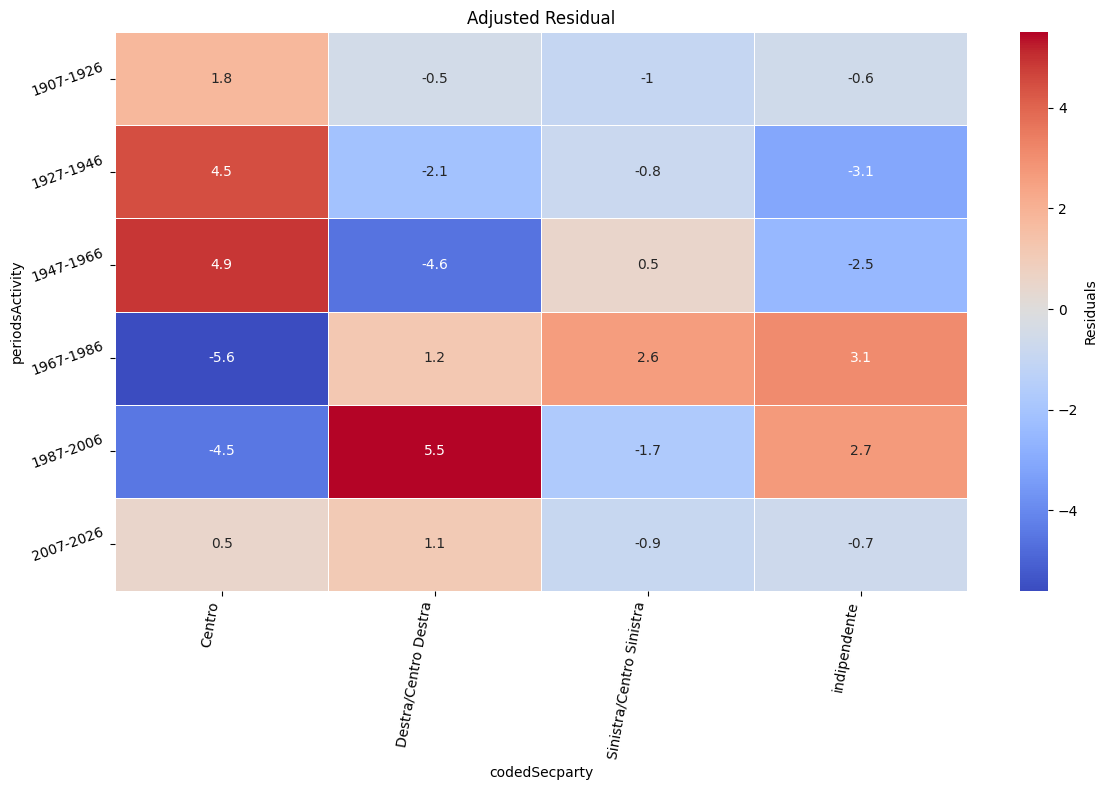

In [136]:
pp = bl.plot_chi2_residuals(observed, figsize=(12,8))

## Secondary occupation (50 categories) vs period

In [137]:
print(dfca.iloc[:50])

codedSecparty
Centro                      214
Sinistra/Centro Sinistra    176
Destra/Centro Destra         98
indipendente                 73
dtype: int64


In [138]:
lc=dfca.iloc[:50].index.to_list()

In [139]:
### Contingency table: 
dfc = df_p[df_p.codedSecparty.isin(lc)]
occ_vs_per=pd.crosstab(dfc.periodsActivity, dfc.codedSecparty, margins=True)
occ_vs_per

codedSecparty,Centro,Destra/Centro Destra,Sinistra/Centro Sinistra,indipendente,All
periodsActivity,,,,,
1907-1926,21,6,10,4,41
1927-1946,44,6,19,1,70
1947-1966,83,8,50,11,152
1967-1986,34,34,65,33,166
1987-2006,18,36,24,21,99
2007-2026,14,8,8,3,33
All,214,98,176,73,561


In [140]:
observed = occ_vs_per.iloc[:-1, :-1 ]

In [141]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


### CA

In [142]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1907-...iodsActivity')
,col_labels,Index(['Centr...odedSecparty')
,stats,True


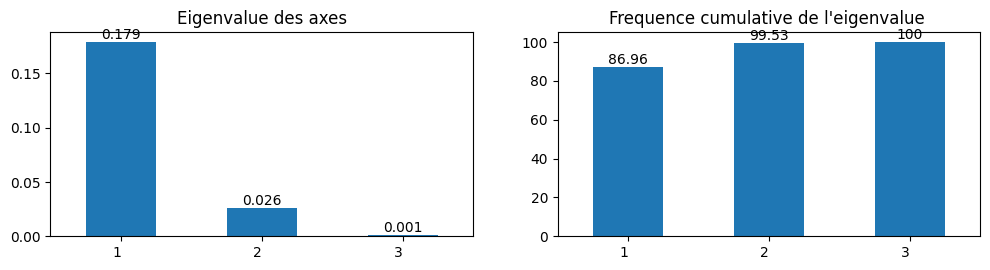

In [143]:
### Inertia (Phi-square - Eigenvalue):  0.083
cal.print_eigenvalue(afc)

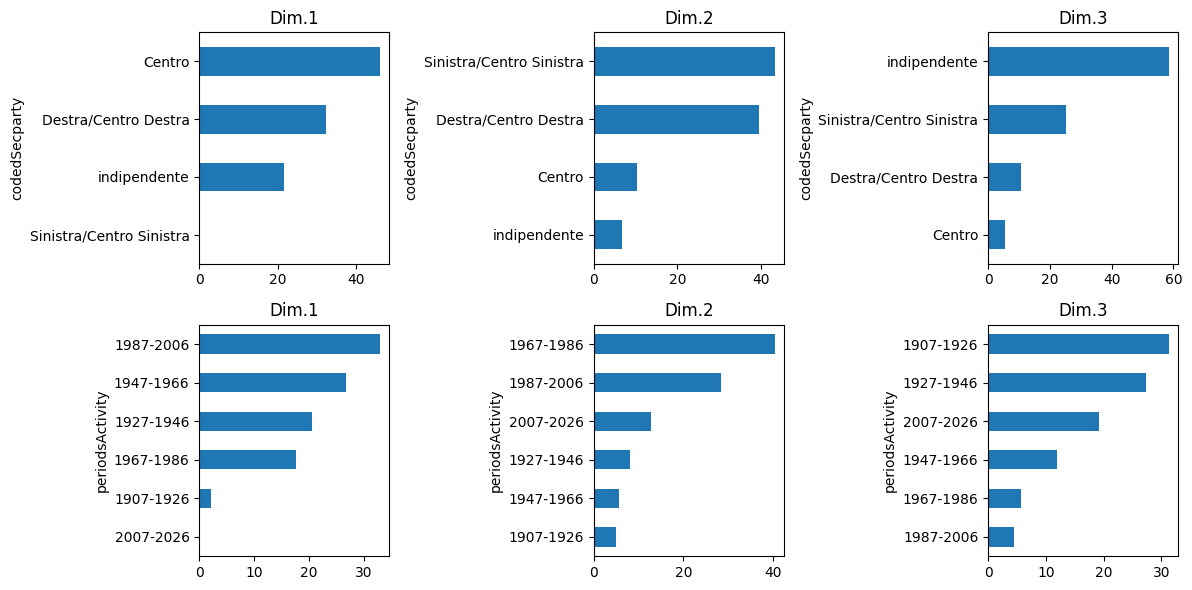

In [144]:
cal.dim_contributions(afc)

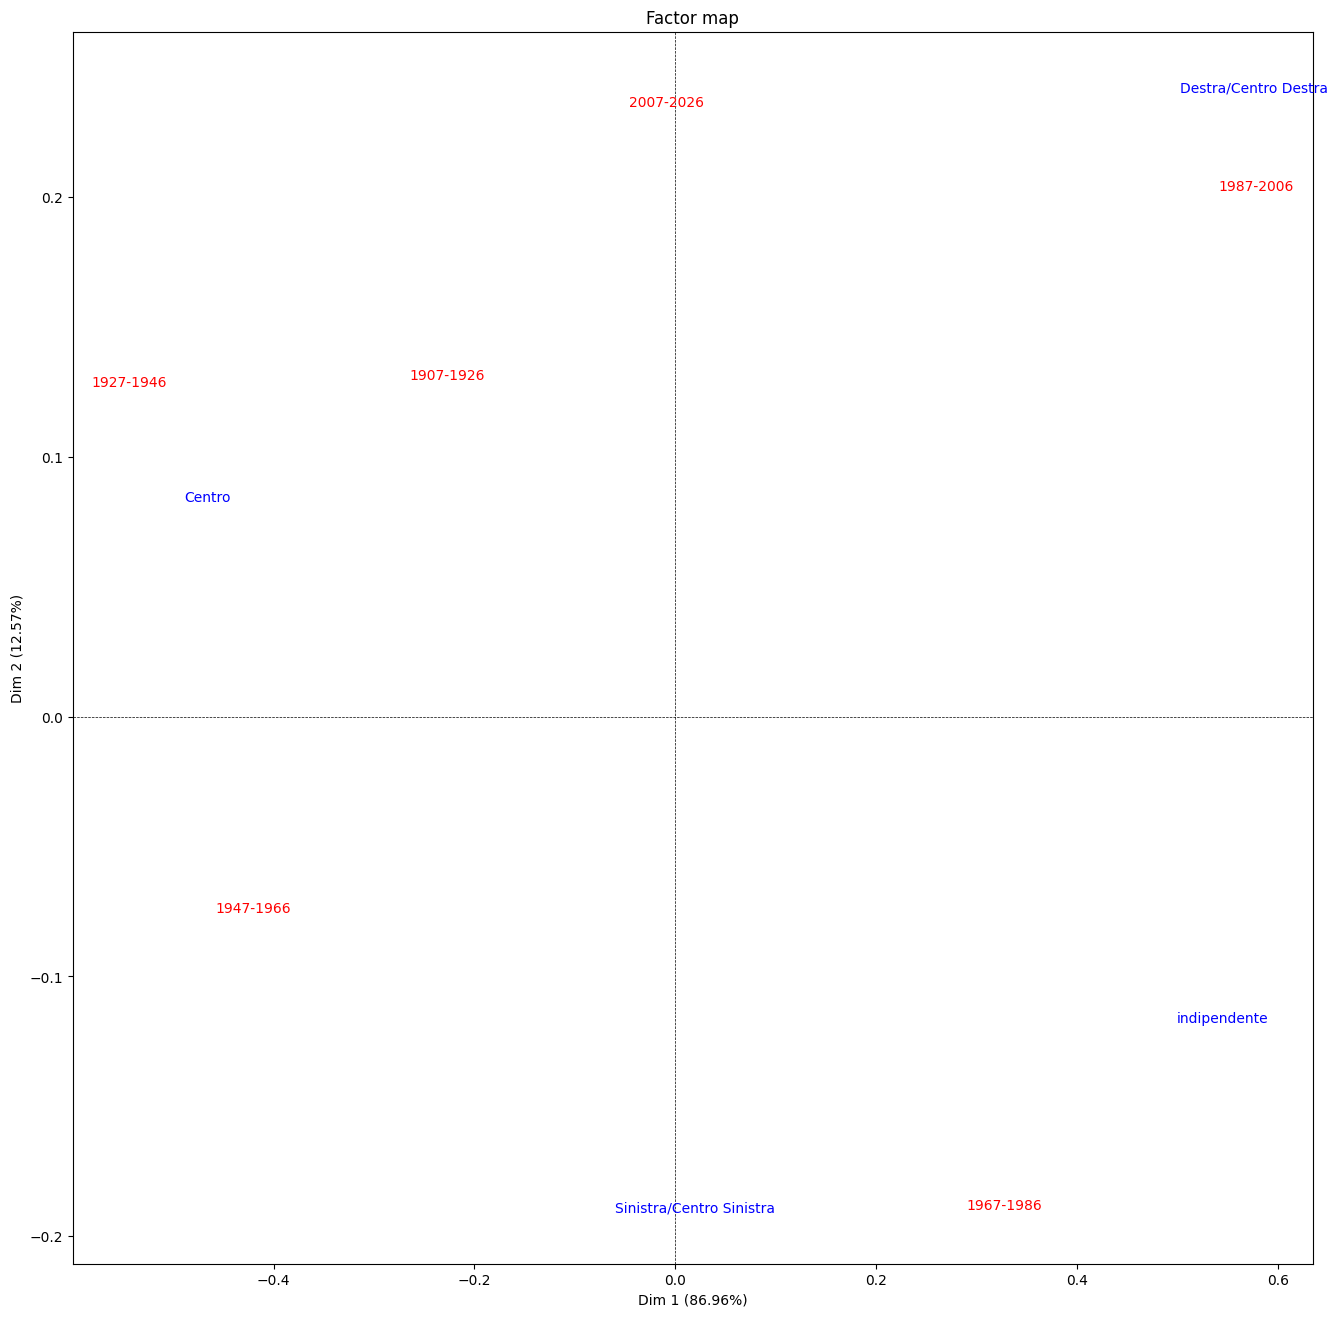

In [145]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(16,16))

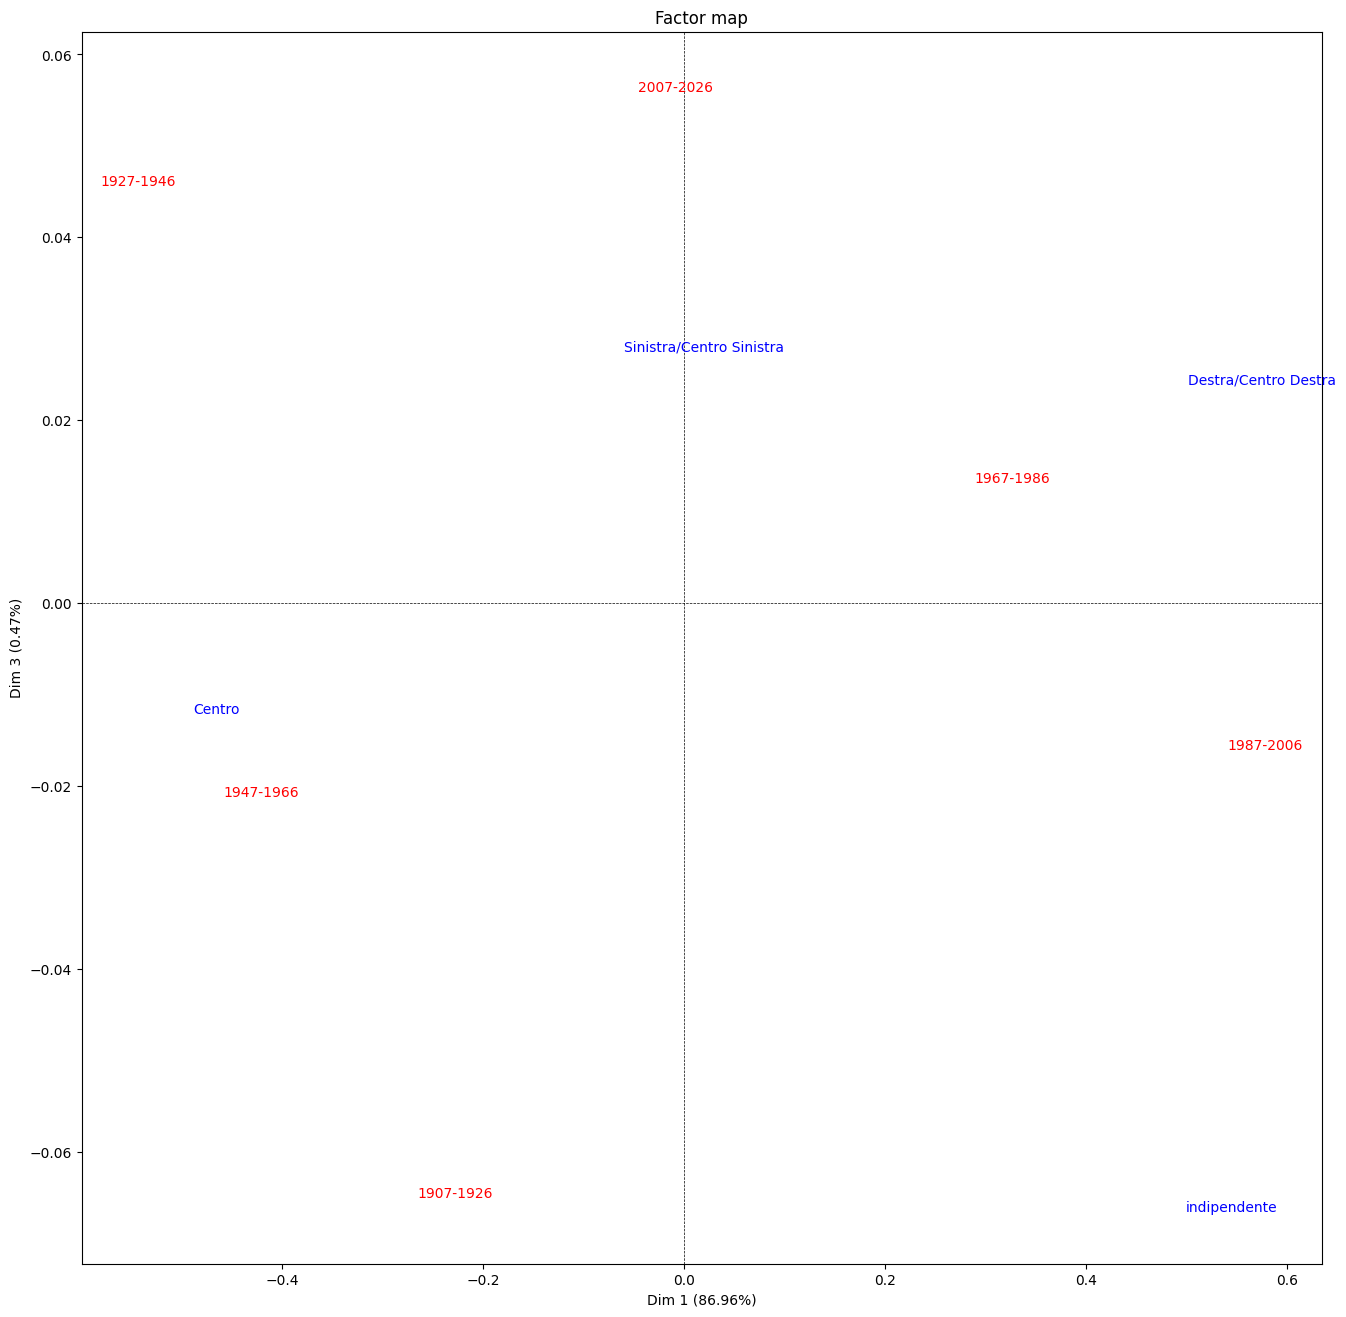

In [146]:
# Represent dimension 1 and 3
afc.mapping(num_x_axis=1,num_y_axis=3,figsize=(16,16))

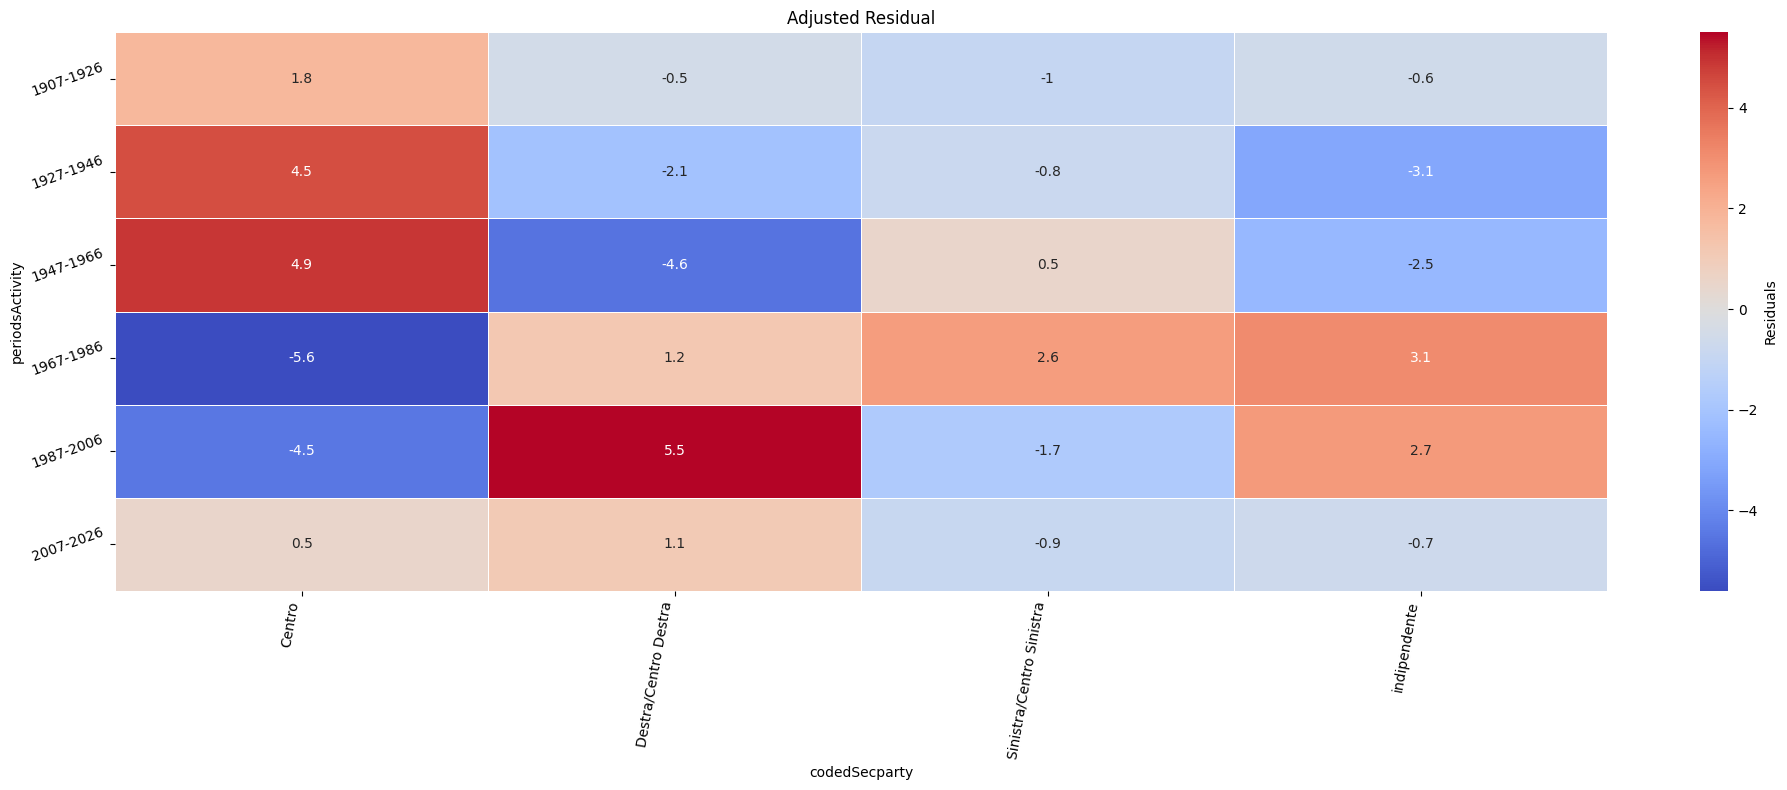

In [147]:
pp = bl.plot_chi2_residuals(observed, figsize=(20,8))

In [148]:
inspect=['centro']
df_p[df_p.codedSecparty.isin(inspect)].iloc[:]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,per_occupation,occup_gen,codedSecparty


### Plot the distribution using actual numbers

In [149]:
observed_f = observed.loc[:, [col for col in observed.columns if col not in ['professor']]]

In [150]:
observed_f=observed_f.reindex(sorted(observed_f.columns, reverse=True), axis=1)


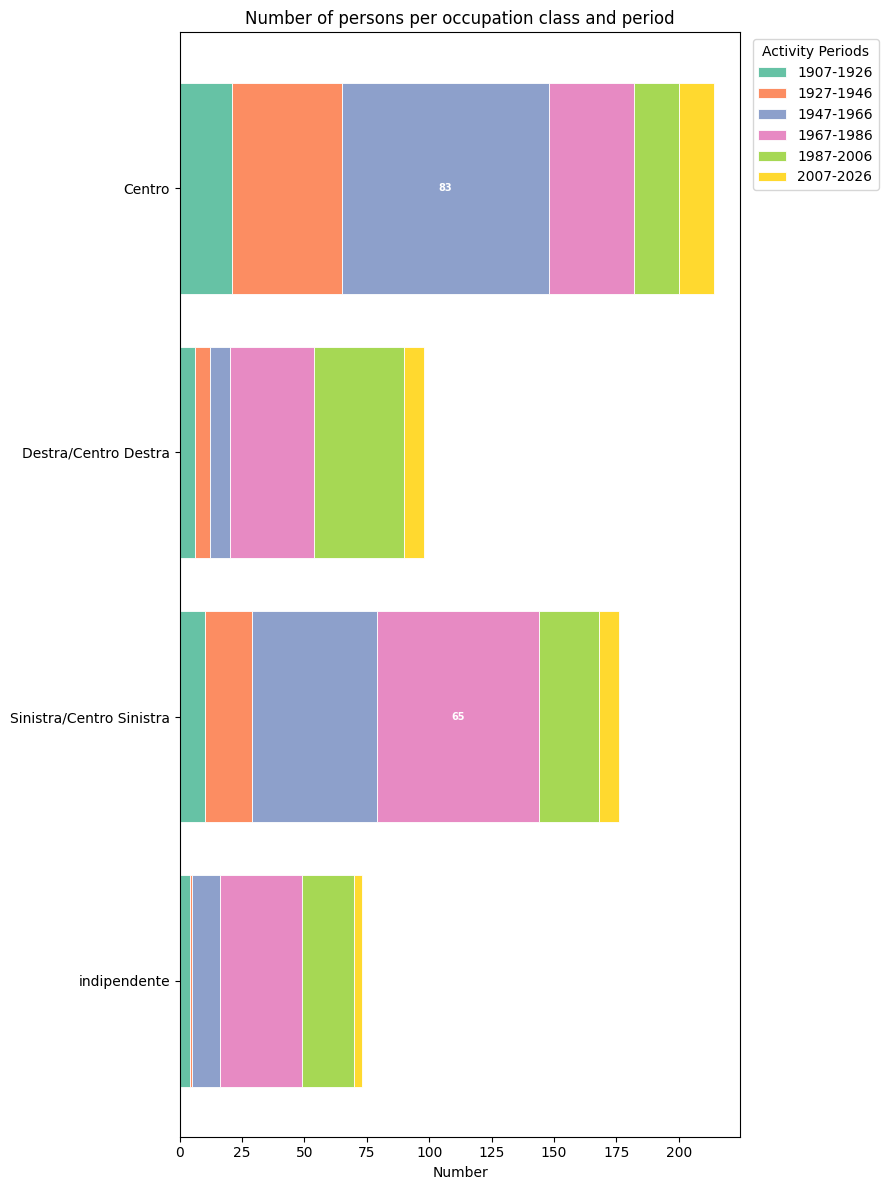

In [151]:

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 12))

colors = plt.cm.Set2.colors
lefts = np.zeros(len(observed_f.columns))  # horizontal accumulator

for i, (row_label, row_vals) in enumerate(observed_f.iterrows()):
    ax.barh(
        observed_f.columns,
        row_vals,
        left=lefts,
        color=colors[i % len(colors)],
        label=row_label,
        edgecolor='white',
        linewidth=0.6,
    )
    # Label inside each segment
    for j, (col, val) in enumerate(zip(observed_f.columns, row_vals)):
        if val > 50:
            ax.text(
                lefts[j] + val / 2, j,
                f'{int(val):,}',
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold'
            )
    lefts += row_vals.values

# --- Fix scientific notation ---
fmt = ScalarFormatter()
fmt.set_scientific(False)
fmt.set_useOffset(False)
ax.xaxis.set_major_formatter(fmt)  # x-axis now holds the counts



# --- Formatting ---
ax.set_xlabel('Number')
ax.set_title('Number of persons per occupation class and period', fontsize=12)
ax.legend(title='Activity Periods', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [152]:
### Apply function and create new column
df_p['party_gen']= df_p.apply(lambda x: np.nan if pd.isna(x.codedSecparty) \
                              else x.codedSecparty +'_'+ code_gender(x.gender), axis=1)

In [153]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,per_occupation,occup_gen,codedSecparty,party_gen
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,1907-1926_m,355.0,politico,sindacalista,NaN,NaN,Partito Socialista Italiano,NaN,355.0,NaN,1907-1926_politico,politico_m,Sinistra/Centro Sinistra,Sinistra/Centro Sinistra_m
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,1907-1926_m,461.0,politico,diplomatico,NaN,NaN,Partito Repubblicano Italiano,NaN,461.0,NaN,1907-1926_politico,politico_m,Sinistra/Centro Sinistra,Sinistra/Centro Sinistra_m


In [154]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_partyGen=pd.crosstab(df_p.periodsActivity, df_p.party_gen, margins=True)
per_vs_partyGen

party_gen,Centro_f,Centro_m,Destra/Centro Destra_f,Destra/Centro Destra_m,Sinistra/Centro Sinistra_f,Sinistra/Centro Sinistra_m,indipendente_f,indipendente_m,All
periodsActivity,,,,,,,,,
1907-1926,0,21,0,6,0,10,0,4,41
1927-1946,0,44,0,6,0,19,0,1,70
1947-1966,2,81,0,8,1,49,0,11,152
1967-1986,3,31,3,31,10,55,3,30,166
1987-2006,4,14,8,28,5,19,5,16,99
2007-2026,6,8,5,3,3,5,1,2,33
All,15,199,16,82,19,157,9,64,561


In [155]:
observed = per_vs_partyGen.iloc[:-1, :-1 ]

In [156]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: False


In [157]:
expected=bl.bivariate_stats(observed)

Chi-square : 206.1 , dof : 35
p-value : 0.0
Inertia (Phi-square):  0.367
Cramer:  0.271


In [158]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1907-...iodsActivity')
,col_labels,Index(['Centr...e='party_gen')
,stats,True


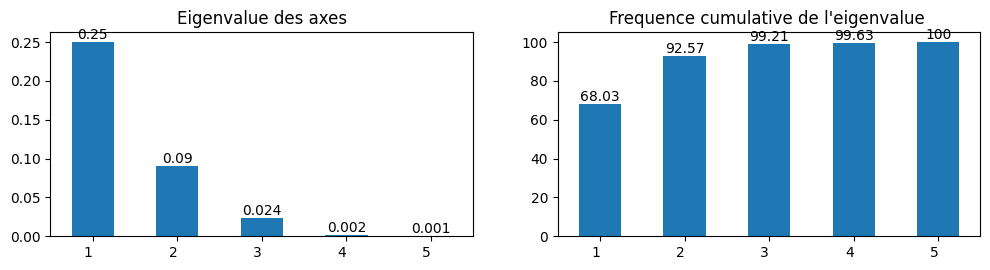

In [159]:
### Inertia (Phi-square - Eigenvalue):  0.083
cal.print_eigenvalue(afc)

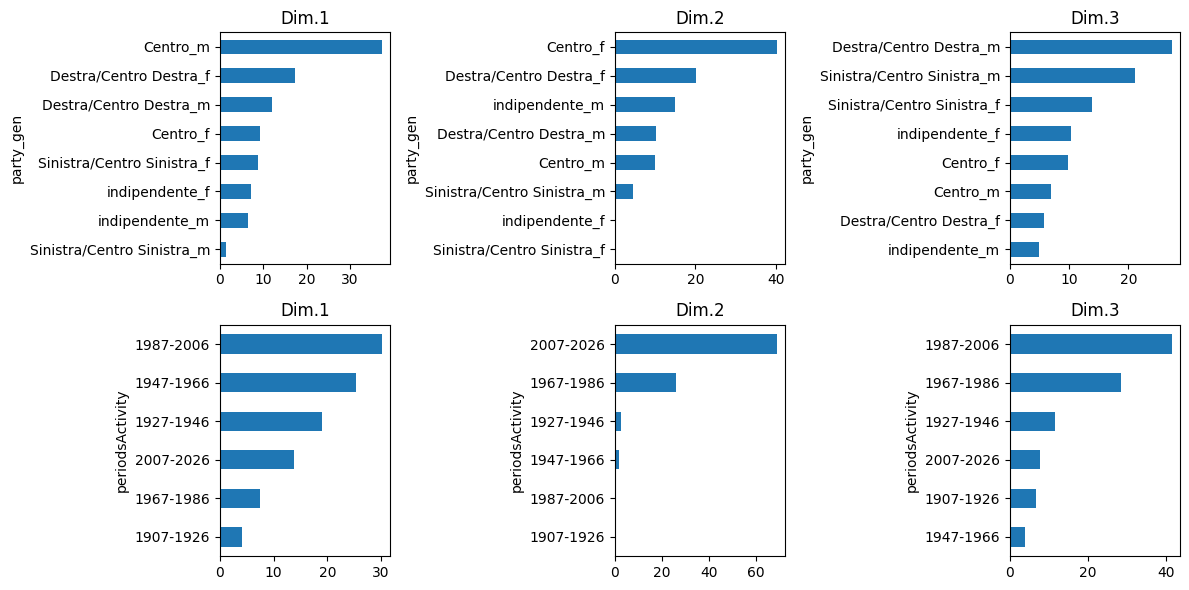

In [160]:
cal.dim_contributions(afc)

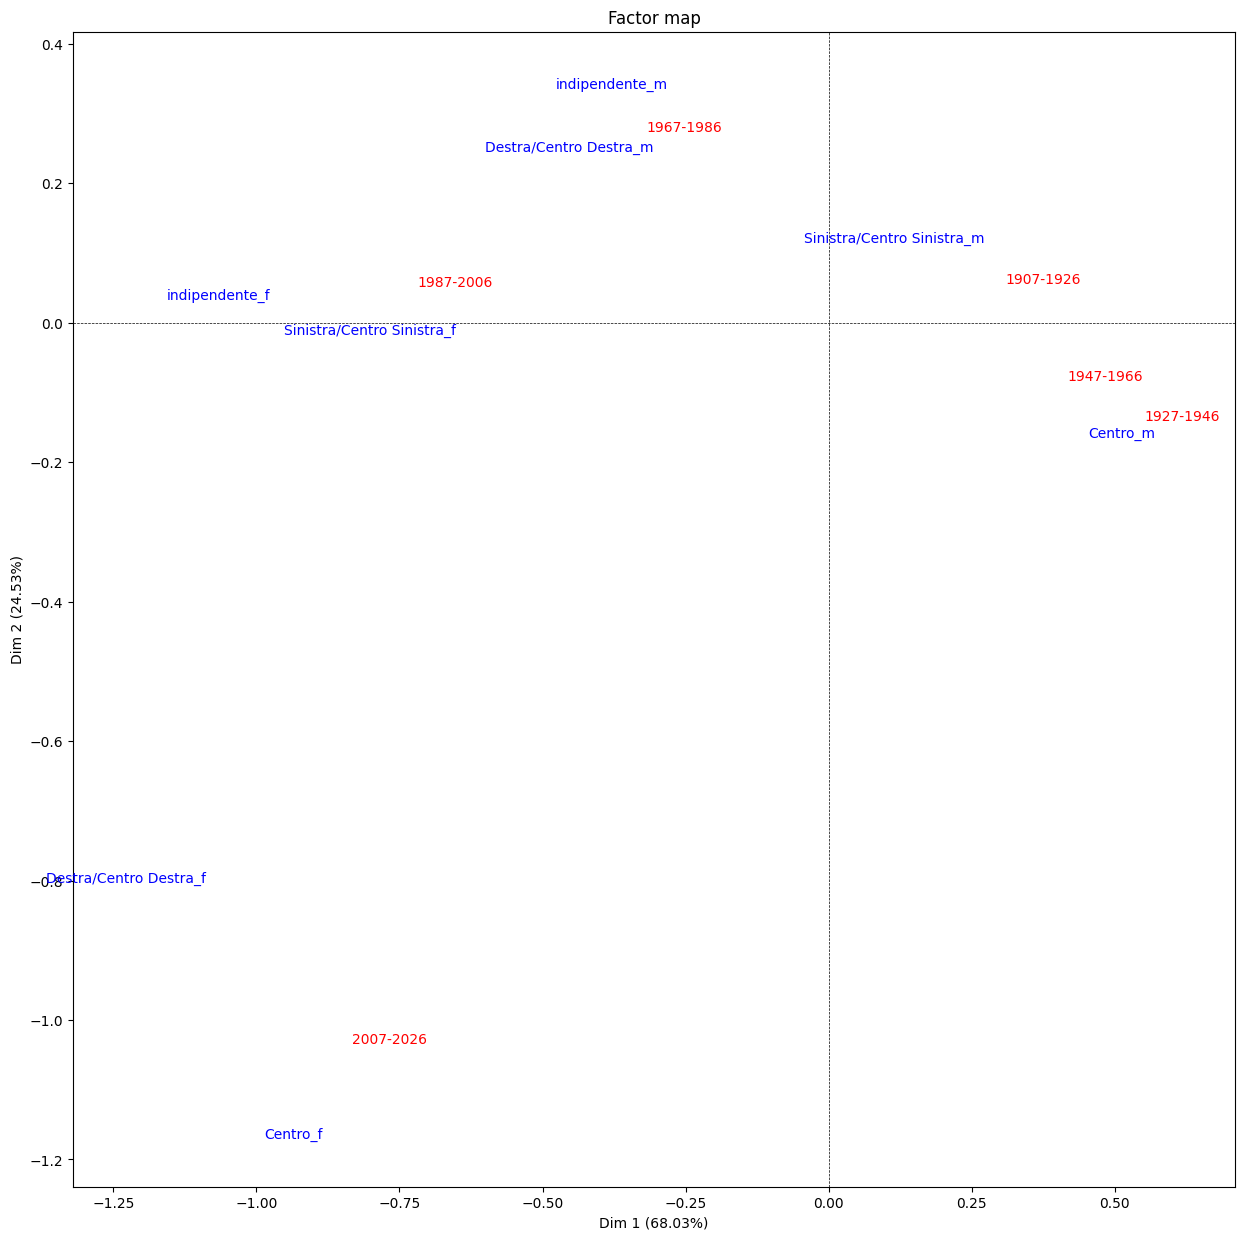

In [161]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(15,15))

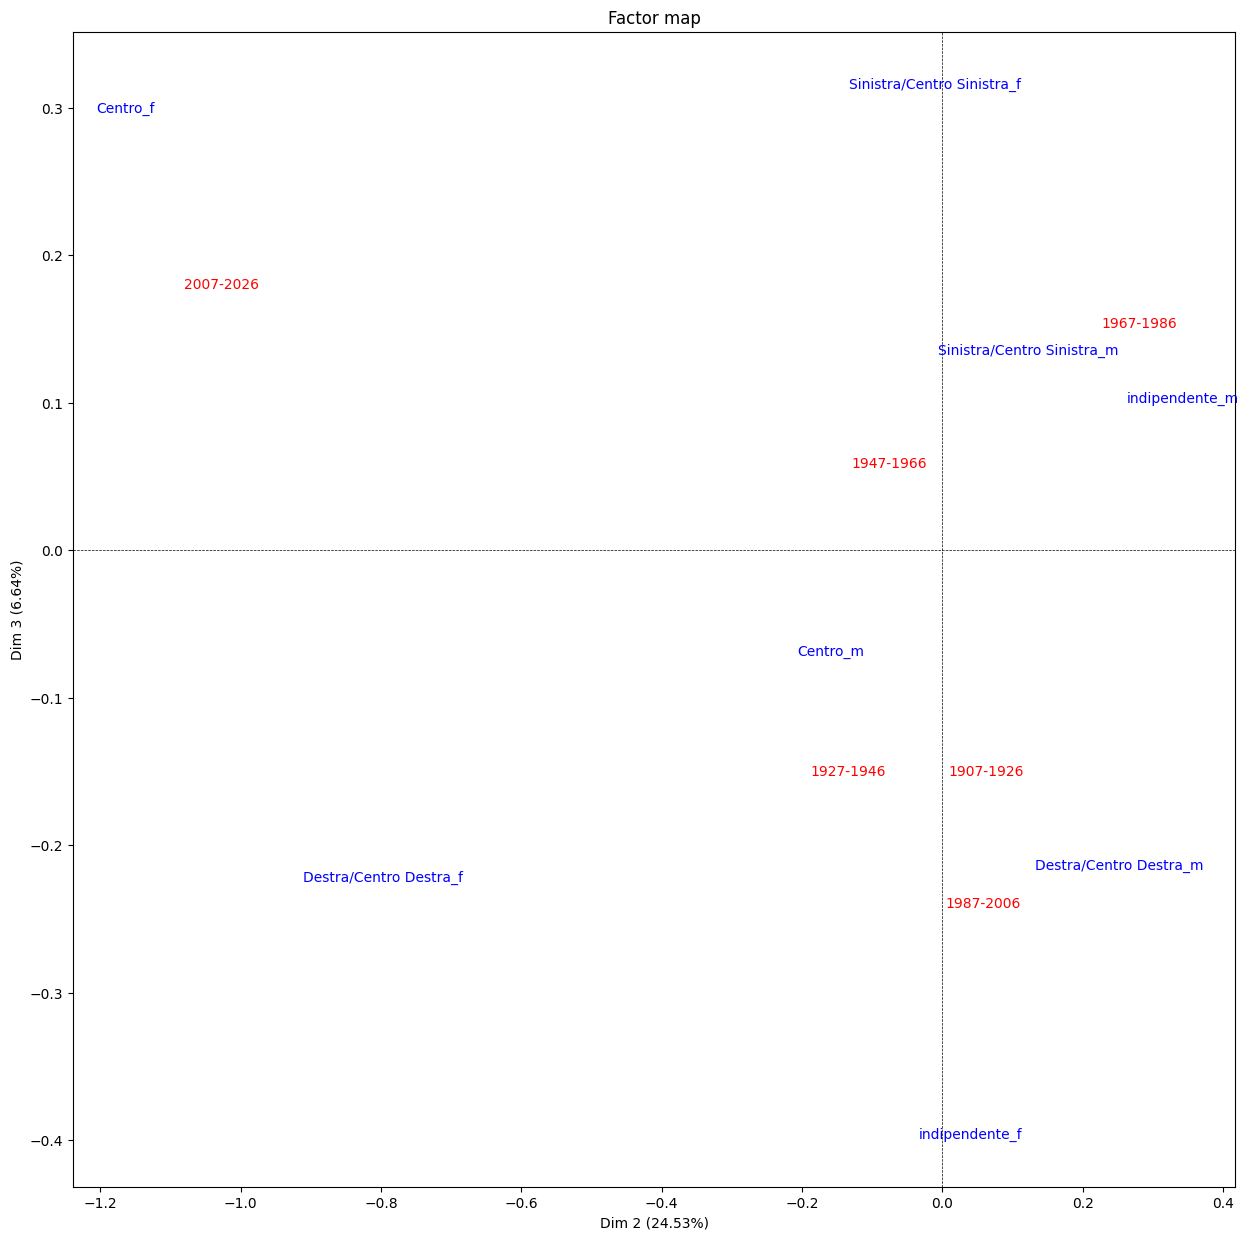

In [162]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(15,15))

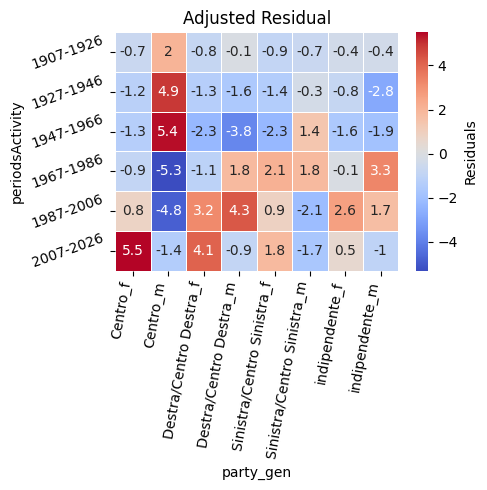

In [163]:
pp = bl.plot_chi2_residuals(observed, figsize=(5, 5))